# Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

Pipeline:
1. **RegEx**: gỡ `@mention`, `#hashtag`, URL, emoji (và một số biểu tượng dạng text).
2. **Chuẩn hóa**: giải mã HTML entity, chữ thường.
3. **Stop words** tiếng Anh + **Lemmatization** (WordNet).

### Import thư viện

In [40]:
import warnings
warnings.filterwarnings("ignore")
import re
import html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from collections import Counter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
import contractions
import emoji

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

### Download packages NLTK

In [2]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

STOP = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hugdo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
negation_words = {"not", "no", "nor", "none", "neither", "never"}
STOP = STOP - negation_words


## 1. Đọc dữ liệu

In [5]:
ROOT = Path("..").resolve()
CSV_PATH = ROOT / "data" / "Tweets.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8")
print(df.shape)
print(df.columns)
df[["airline_sentiment", "airline", "text"]]

(14640, 15)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')


,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14635,positive,American,@AmericanAir thank you we got on a different f...
14636,negative,American,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,American,@AmericanAir Please bring American Airlines to...
14638,negative,American,"@AmericanAir you have my money, you change my ..."


### Thông tin cơ bản về Dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

In [7]:
print(df['airline_sentiment'].value_counts())


airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [8]:
df['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

### Kiểm tra Duplicates

In [9]:
print(f"Tổng số dòng: {len(df):,}")
print(f"Số dòng duplicate (toàn bộ): {df.duplicated().sum():,}")
print(f"Số dòng duplicate (chỉ text): {df.duplicated(subset=['text']).sum():,}")

Tổng số dòng: 14,640
Số dòng duplicate (toàn bộ): 36
Số dòng duplicate (chỉ text): 213


## 2. Làm sạch bằng Regular Expression

- **URL**: `http(s)://...`, `www....`, rút gọn `t.co/...`
- **@mention**: `@handle`
- **#hashtag**: `#tag`
- **Emoji**: các khối Unicode phổ biến + emoticon kiểu `:-)` `:D`

Sau đó **html.unescape** để xử lý `&amp;`, `&lt;`, v.v.

In [12]:
# Ví dụ về xử lý Hashtag
print(segment("#worstflightever")) 

['worst', 'flight', 'ever']


In [16]:
# Ví dụ về xử lý icon
emoji.demojize("😡 💯") # "😡" -> ":enraged_face:"

':enraged_face: :hundred_points:'

In [19]:
# Ví dụ về xử lý segment từ
from wordsegment import load, segment
load()
print(segment("Hello i do not like worstflightever enraged_face :enraged_face:")) 

['hello', 'i', 'do', 'not', 'like', 'worst', 'flight', 'ever', 'enraged', 'face', 'enraged', 'face']


In [15]:
# Ví dụ về xử lý contractions
contractions.fix("don't") # "don't" -> "do not"

'do not'

#### Xử lý hashtag

In [13]:
import re
from wordsegment import segment

def process_hashtag(match):
    # Lấy toàn bộ cụm hashtag bắt được (VD: r"#worstflightever")
    hashtag_text = match.group(0) 
    
    # Bỏ dấu '#' ở đầu đi để lấy phần chữ (VD: "worstflightever")
    clean_text = hashtag_text.replace('#', '') 
    
    # Gọi hàm segment trên phần chữ (Hàm trả về 1 list: ['worst', 'flight', 'ever'])
    segmented_list = segment(clean_text)
    
    # Nối lại bằng khoảng trắng và trả về chuỗi thay thế
    return " " + " ".join(segmented_list) + " "


# 2. Áp dụng vào văn bản
text = "The food is so dry #worstflightever 😡"

# Truyền trực tiếp hàm `process_hashtag` vào re.sub
# Lúc này Regex chỉ tìm dấu #, tìm được thì bốc cái chữ quăng vào hàm segment, còn lại giữ nguyên
RE_HASHTAG = re.compile(r"#\w+")

text = RE_HASHTAG.sub(process_hashtag, text)

print(text)


The food is so dry  worst flight ever  😡


#### Toàn bộ flow xử lý làm sạch xử liệu

In [20]:
# Regex
RE_URL = re.compile(
    r"https?://\S+|www\.\S+", re.IGNORECASE
)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#\w+")

# # Text emoticon dạng ký tự: =))); :);...
# RE_TEXT_EMOTICONS = re.compile(
#     r"(?::|;|=)(?:[-']?)(?:\)|\(|D|P|S|\\|/|\[|\]|\||\^|o|O|3|>|<|x|X)(?![\w])"
#     r"|(?:\^_|\^_\^|>\.<|T_T|\\o/)",
#     re.IGNORECASE,
# )

RE_NUMBERS = re.compile(r'\d+')
RE_SPECIAL_CHARS = re.compile(r"[^a-zA-Z\s_]")
RE_ELONGATED = re.compile(r'(.)\1+')
RE_MULTI_SPACE = re.compile(r"\s+")


def clean_text_regex(raw: str) -> str:
    """Loại URL, mention, hashtag, emoji bằng RegEx; chuẩn hóa khoảng trắng."""
    if not isinstance(raw, str) or not raw.strip():
        return ""
    
    t = html.unescape(raw)
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = contractions.fix(t) # "don't" -> "do not"
    t = RE_HASHTAG.sub(process_hashtag, t)
    t = emoji.demojize(t) # "😡" -> ":enraged_face:"
    t = RE_SPECIAL_CHARS.sub(" ", t)
    t = RE_ELONGATED.sub(r'\1\1', t)
    t = RE_MULTI_SPACE.sub(" ", t).lower().strip()
    return t

In [21]:
samples = df["text"].dropna().head(8).tolist()
for s in samples:
    print("---")
    print("Gốc:  ", s[:120], "..." if len(s) > 120 else "")
    print("Sạch: ", clean_text_regex(s)[:120], "..." if len(clean_text_regex(s)) > 120 else "")

---
Gốc:   @VirginAmerica What @dhepburn said. 
Sạch:  what said 
---
Gốc:   @VirginAmerica plus you've added commercials to the experience... tacky. 
Sạch:  plus you have added commercials to the experience tacky 
---
Gốc:   @VirginAmerica I didn't today... Must mean I need to take another trip! 
Sạch:  i did not today must mean i need to take another trip 
---
Gốc:   @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little re ...
Sạch:  it is really aggressive to blast obnoxious entertainment in your guests faces they have little recourse 
---
Gốc:   @VirginAmerica and it's a really big bad thing about it 
Sạch:  and it is a really big bad thing about it 
---
Gốc:   @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing ...
Sạch:  seriously would pay a flight for seats that did not have this playing it is really the only bad thing about flying va 
---
Gốc:   @

## 3. Tokenize, bỏ stop words, lemmatize

Ánh xạ POS (Penn Treebank => WordNet) để lemmatize động từ/tính từ chính xác hơn.

In [22]:
def treebank_to_wordnet(tag: str):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess_pipeline(text: str) -> str:
    """RegEx > token > lower > bỏ stopword > lemma > chuỗi kết quả."""
    cleaned = clean_text_regex(text)
    if not cleaned:
        return ""
    tokens = word_tokenize(cleaned)
    # Chỉ giữ token chữ thuần túy để giảm nhiễu tweet (bỏ số, ký tự đặc biệt, URL đã gỡ)
    # Ví dụ: giữ "flight", bỏ "A321" hoặc "100"; nếu cần giữ từ ngữ chứa apostrophe, hãy mở rộng regex.
   
    tagged = pos_tag(tokens)
    lemmas = [
        LEMMATIZER.lemmatize(w, treebank_to_wordnet(tag)) for w, tag in tagged
    ]
    
    final_tokens = [w for w in lemmas if w not in STOP and len(w) > 1]
    return " ".join(lemmas)

In [23]:
df["text_cleaned"] = df["text"].astype(str).map(clean_text_regex)
df["text_preprocessed"] = df["text"].astype(str).map(preprocess_pipeline)

compare = df[["text", "text_cleaned", "text_preprocessed"]].head(12)
compare

,text,text_cleaned,text_preprocessed
0,@VirginAmerica What @dhepburn said.,what said,what say
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experie...,plus you have add commercial to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i did not today must mean i need to take anoth...,i do not today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,it is really aggressive to blast obnoxious ent...,it be really aggressive to blast obnoxious ent...
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it,and it be a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...,seriously would pay a flight for seat that do ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...,yes nearly every time i fly vx this ear worm w...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...,really miss a prime opportunity for men withou...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i did not but now i do d,well i do not but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early you a...,it be amaze and arrive an hour early you be to...


### Save kết quả sau khi xử lý

In [24]:
# Save
out = ROOT / "data" / "Tweets_preprocessed.csv"
df.to_csv(out, index=False, encoding="utf-8")
print("Save to:", out)

Save to: D:\hungdo\Airline-Sentiment\data\Tweets_preprocessed.csv


# Khai phá dữ liệu

### Plot 1: Number of tweets by airline

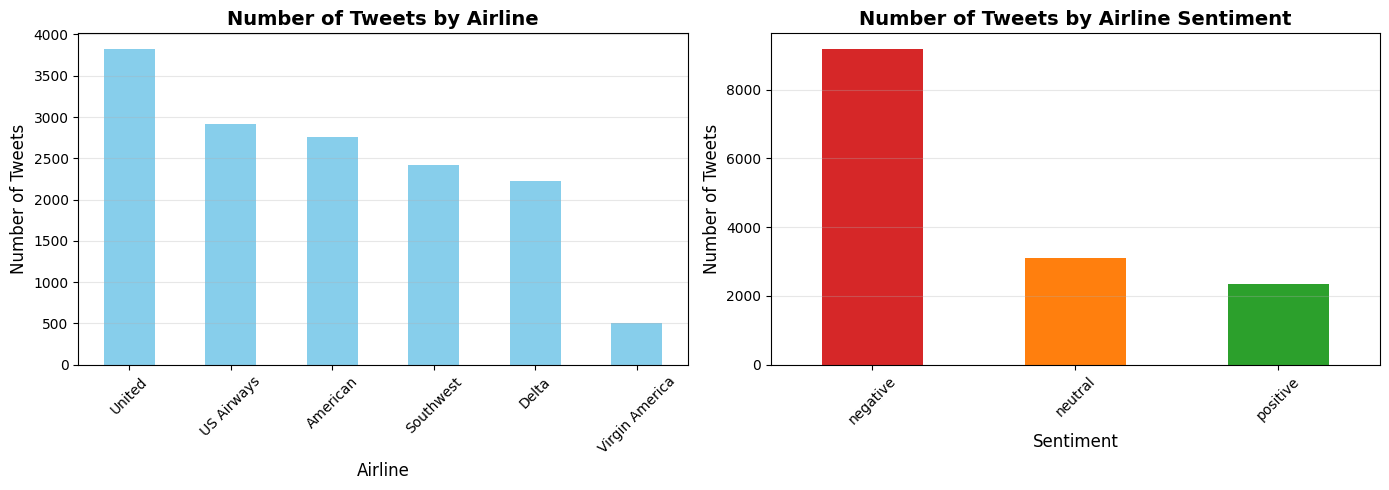

Total number of tweets: 14640

Tweets by Airline:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

Tweets by Sentiment:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count tweets by airline
airline_counts = df['airline'].value_counts()
airline_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Number of Tweets by Airline', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Airline', fontsize=12)
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Number of tweets by airline sentiment
sentiment_counts = df['airline_sentiment'].value_counts()
colors = ['#d62728', '#ff7f0e', '#2ca02c']  # red, orange, green
sentiment_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Number of Tweets by Airline Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Number of Tweets', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total number of tweets: {len(df)}")
print(f"\nTweets by Airline:\n{airline_counts}")
print(f"\nTweets by Sentiment:\n{sentiment_counts}")

### Compute sentiment totals per airline and determine most hated / most loved

In [26]:
sentiment_by_airline = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
print('Sentiment counts by airline:')
print(sentiment_by_airline)

most_hated_airline = sentiment_by_airline['negative'].idxmax()
most_hated_count = sentiment_by_airline['negative'].max()
most_loved_airline = sentiment_by_airline['positive'].idxmax()
most_loved_count = sentiment_by_airline['positive'].max()

print('\nMost hated airline (highest negative tweets):')
print(f'- {most_hated_airline} ({most_hated_count} negative tweets)')

print('\nMost loved airline (highest positive tweets):')
print(f'- {most_loved_airline} ({most_loved_count} positive tweets)')

Sentiment counts by airline:
airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152

Most hated airline (highest negative tweets):
- United (2633 negative tweets)

Most loved airline (highest positive tweets):
- Southwest (570 positive tweets)


### Visualize most hated / most loved by airline with percent-based sentiment

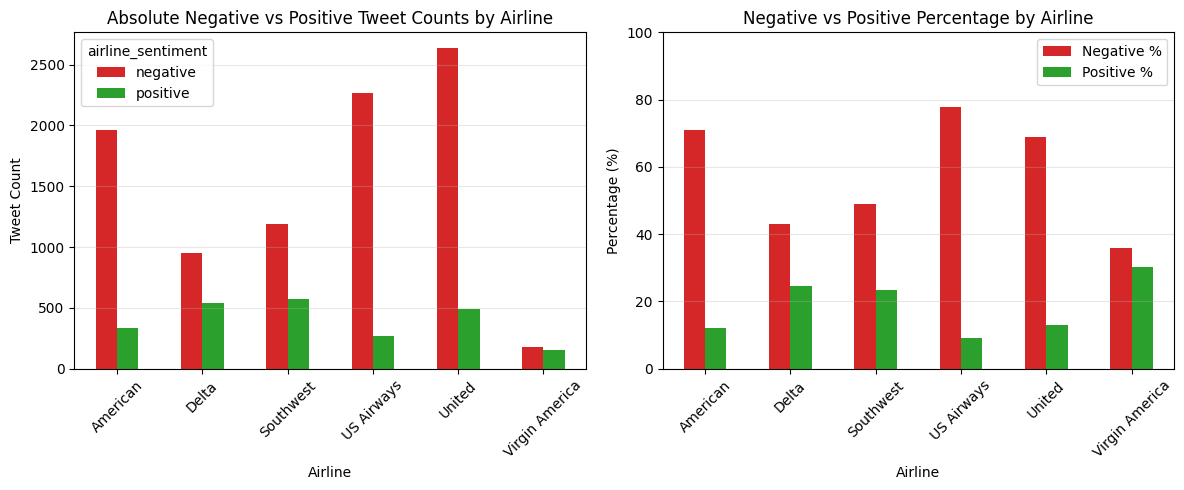


Most hated (highest absolute negative): United
Most loved (highest absolute positive): Southwest

Hate/Love percentages by airline (sorted by negative % descending):
airline_sentiment  negative_pct  positive_pct
airline                                      
US Airways            77.686234      9.234466
American              71.040232     12.178325
United                68.890633     12.872841
Southwest             49.008264     23.553719
Delta                 42.979298     24.482448
Virgin America        35.912698     30.158730


In [27]:
sentiment_by_airline = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)

# Add totals and percentages
sentiment_by_airline['total'] = sentiment_by_airline.sum(axis=1)
sentiment_by_airline['positive_pct'] = sentiment_by_airline['positive'] / sentiment_by_airline['total'] * 100
sentiment_by_airline['negative_pct'] = sentiment_by_airline['negative'] / sentiment_by_airline['total'] * 100

# Plot absolute counts side-by-side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sentiment_by_airline[['negative', 'positive']].plot(kind='bar', stacked=False, color=['#d62728', '#2ca02c'], ax=plt.gca())
plt.title('Absolute Negative vs Positive Tweet Counts by Airline')
plt.xlabel('Airline')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Plot percentage sentiment so haters/lovers per brand are visible
plt.subplot(1, 2, 2)
ax = sentiment_by_airline[['negative_pct', 'positive_pct']].plot(kind='bar', stacked=False, color=['#d62728', '#2ca02c'], ax=plt.gca())
ax.set_title('Negative vs Positive Percentage by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.legend(['Negative %', 'Positive %'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Annotate and display ranked results for clarity
print('\nMost hated (highest absolute negative):', most_hated_airline)
print('Most loved (highest absolute positive):', most_loved_airline)
print('\nHate/Love percentages by airline (sorted by negative % descending):')
print(sentiment_by_airline[['negative_pct', 'positive_pct']].sort_values('negative_pct', ascending=False))

### Draw each airline's top 3 negative reasons in a consistent horizontal bar grid layout (aligned to your example image)

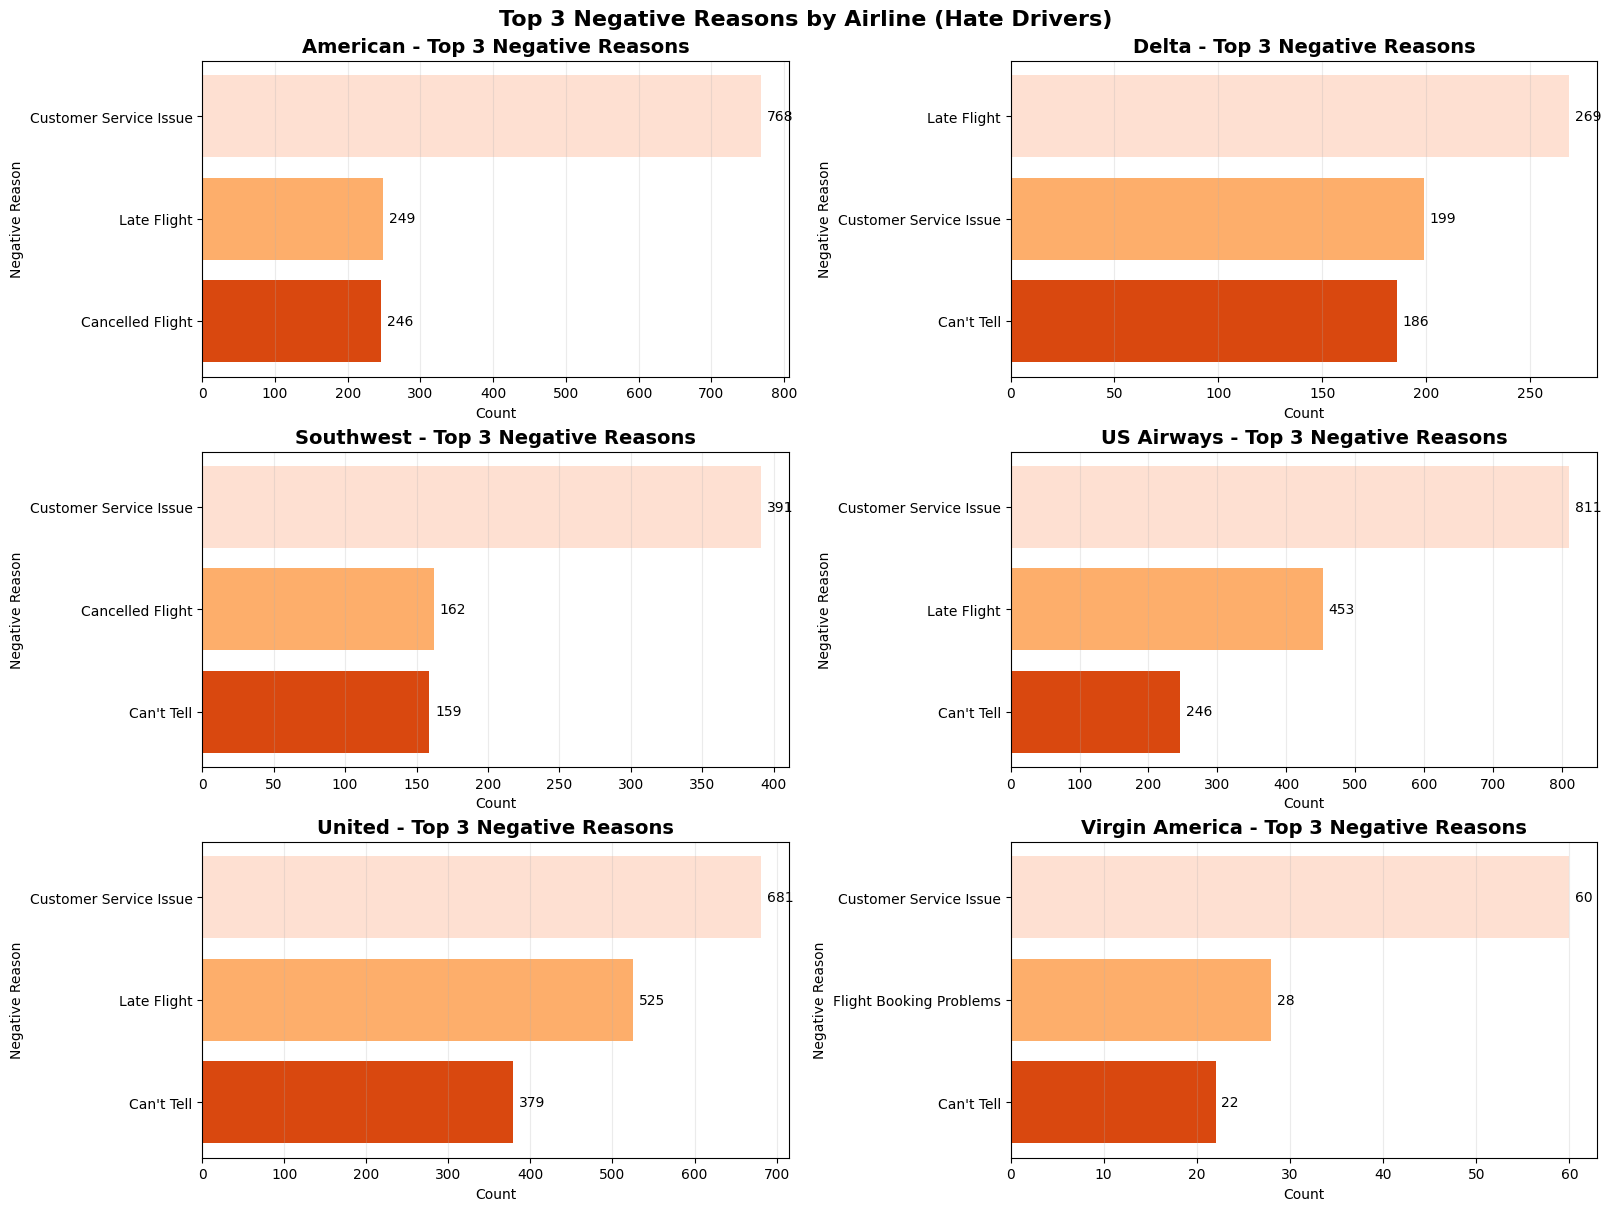

In [28]:
# Ensure `top3_reasons` is defined (recompute if kernel restarted)
if 'top3_reasons' not in globals():
    reason_by_airline = df[df['airline_sentiment'] == 'negative'].groupby(['airline', 'negativereason']).size().reset_index(name='count')
    top3_reasons = reason_by_airline.sort_values(['airline','count'], ascending=[True, False]).groupby('airline').head(3)

airline_list = top3_reasons['airline'].unique()
num_airlines = len(airline_list)
cols = 2
rows = (num_airlines + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), constrained_layout=True)
axes = axes.flatten()

for i, airline in enumerate(airline_list):
    ax = axes[i]
    data = top3_reasons[top3_reasons['airline'] == airline].sort_values('count', ascending=True)
    ax.barh(data['negativereason'], data['count'], color=['#d9480f', '#fdae6b', '#fee0d2'])
    ax.set_title(f'{airline} - Top 3 Negative Reasons', fontsize=14, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('Negative Reason')
    for j, v in enumerate(data['count']):
        ax.text(v + max(data['count']) * 0.01, j, str(v), va='center', fontsize=10)
    ax.grid(axis='x', alpha=0.25)

# Hide extra axes if present
for i in range(num_airlines, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Top 3 Negative Reasons by Airline (Hate Drivers)', fontsize=16, fontweight='bold')
plt.show()

### Liên kết text với airline_sentiment: trích xuất n-grams biểu hiện giận dữ

Training Logistic Regression...
Training Random Forest...
LR test accuracy: 0.8268, RF test accuracy: 0.8197

Top n-grams gợi ý giận dữ (Logistic Regression, coef dương):
               ngram      coef
792              bad  2.251391
13232       terrible  2.238076
12958           suck  2.187245
7298            fuck  2.168813
12114          screw  2.164376
7285       frustrate  2.071847
6301            fail  1.976831
8078            hour  1.974392
7667            hang  1.901778
9401         luggage  1.866729
9069             lie  1.848407
14102   unacceptable  1.842415
11813     ridiculous  1.839584
8239             hrs  1.768470
11897           rude  1.755817
9291            lose  1.717831
84        acceptable  1.672725
3795           delay  1.662562
8203              hr  1.621903
1898   communication  1.605458
14848          worst  1.594488
5158    disappointed  1.590567
12861          stick  1.541849
8253           human  1.485352
7289     frustrating  1.478989

Top n-grams gợi thích 

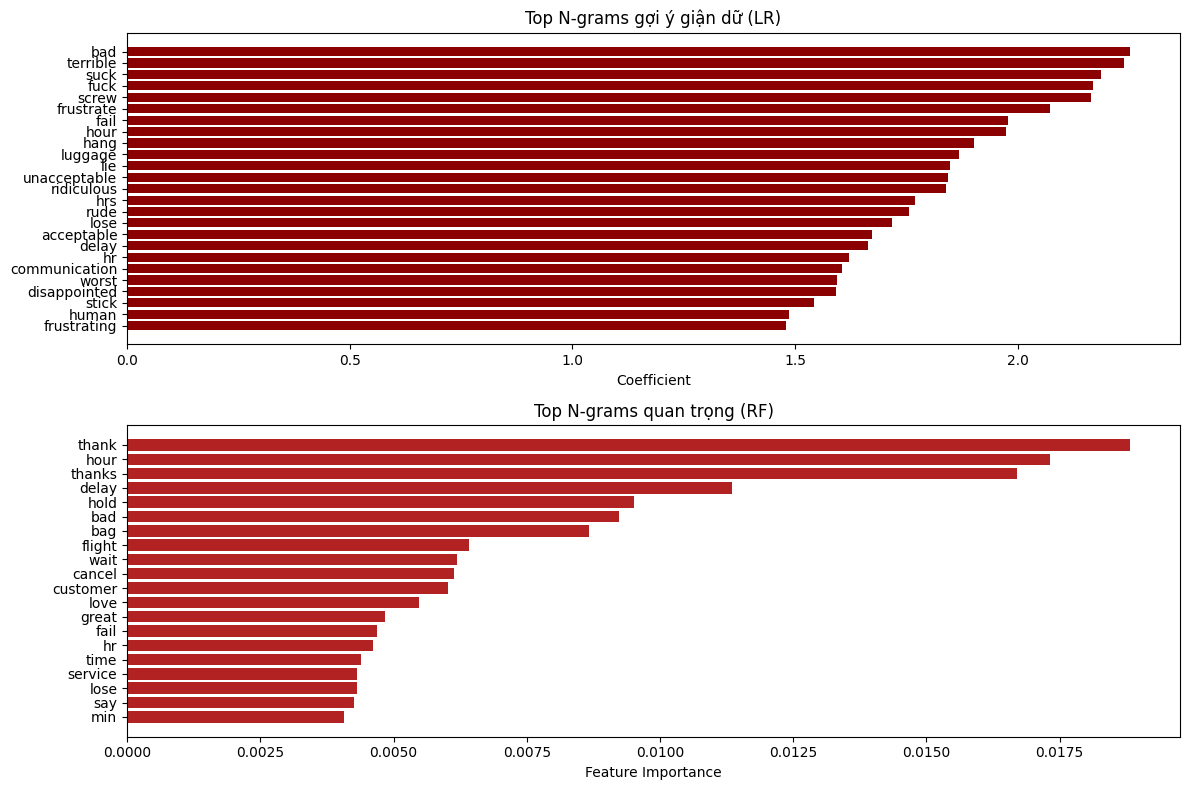

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Chọn cột text đã xử lý (text_preprocessed nếu có, ngược lại text)
text_col = 'text_preprocessed' if 'text_preprocessed' in df.columns else 'text'

# Gán nhãn: negative = 1, others = 0
X = df[text_col].fillna('')
y = (df['airline_sentiment'] == 'negative').astype(int)

# Chia train/test để ước đoán và đánh giá
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline LR
lr_pipeline = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=15000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Pipeline RF
rf_pipeline = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=15000, stop_words='english')),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1))
])

print('Training Logistic Regression...')
lr_pipeline.fit(X_train, y_train)
print('Training Random Forest...')
rf_pipeline.fit(X_train, y_train)

# In ra một số độ chính xác
lr_score = lr_pipeline.score(X_test, y_test)
rf_score = rf_pipeline.score(X_test, y_test)
print(f'LR test accuracy: {lr_score:.4f}, RF test accuracy: {rf_score:.4f}')

# Trích n-gram quan trọng từ Logistic Regression
vectorizer = lr_pipeline.named_steps['vect']
lr_coef = lr_pipeline.named_steps['clf'].coef_[0]
feature_names = np.array(vectorizer.get_feature_names_out())

topn = 25
coef_df = pd.DataFrame({'ngram': feature_names, 'coef': lr_coef})
coef_df['abs_coef'] = coef_df['coef'].abs()

# N-gram hàng đầu với coefficient dương (gợi ý giận dữ)
top_negative_ngrams = coef_df.sort_values('coef', ascending=False).head(topn)
print('\nTop n-grams gợi ý giận dữ (Logistic Regression, coef dương):')
print(top_negative_ngrams[['ngram','coef']])

# n-gram với coefficient âm (gợi ý không giận dữ) để so sánh
top_non_negative_ngrams = coef_df.sort_values('coef', ascending=True).head(15)
print('\nTop n-grams gợi thích nghi (không giận dữ):')
print(top_non_negative_ngrams[['ngram','coef']])

# Từ Random Forest: feature importance
rf_vectorizer = rf_pipeline.named_steps['vect']
rf_importances = rf_pipeline.named_steps['clf'].feature_importances_
rf_feature_names = np.array(rf_vectorizer.get_feature_names_out())
rf_df = pd.DataFrame({'ngram': rf_feature_names, 'importance': rf_importances})
rf_top = rf_df.sort_values('importance', ascending=False).head(20)
print('\nTop n-grams (Random Forest importance):')
print(rf_top)

# Vẽ n-grams đặc trưng (LR & RF)
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(top_negative_ngrams['ngram'][::-1], top_negative_ngrams['coef'][::-1], color='darkred')
plt.title('Top N-grams gợi ý giận dữ (LR)')
plt.xlabel('Coefficient')
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.barh(rf_top['ngram'][::-1], rf_top['importance'][::-1], color='firebrick')
plt.title('Top N-grams quan trọng (RF)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()


=== Airline: Virgin America ===
Top n-grams liên quan giận dữ: ['site', 'website', 'delay', 'seat', 'try', 'luggage', 'check', 'bad', 'email', 'suck']
Top n-grams không giận: ['love', 'thanks', 'great', 'austin', 'new', 'best', 'team', 'oscar', 'route', 'cool']

=== Airline: United ===
Top n-grams liên quan giận dữ: ['bad', 'charge', 'say', 'delay', 'hour', 'lose', 'fail', 'terrible', 'miss', 'wifi']
Top n-grams không giận: ['thank', 'awesome', 'thanks', 'try flight', 'hi', 'compliment', 'amaze', 'wonderful', 'visit', 'definitely']

=== Airline: Southwest ===
Top n-grams liên quan giận dữ: ['bad', 'luggage', 'hour', 'bag', 'hold', 'delay', 'hr', 'lose', 'website', 'wifi']
Top n-grams không giận: ['thank', 'awesome', 'best', 'thanks', 'passbook', 'atlanta', 'appreciate', 'denver', 'love', 'chance']

=== Airline: Delta ===
Top n-grams liên quan giận dữ: ['hour', 'delay', 'stop', 'tv', 'bad', 'option', 'lose', 'respond', 'suck', 'hate']
Top n-grams không giận: ['thanks', 'thank', 'love',

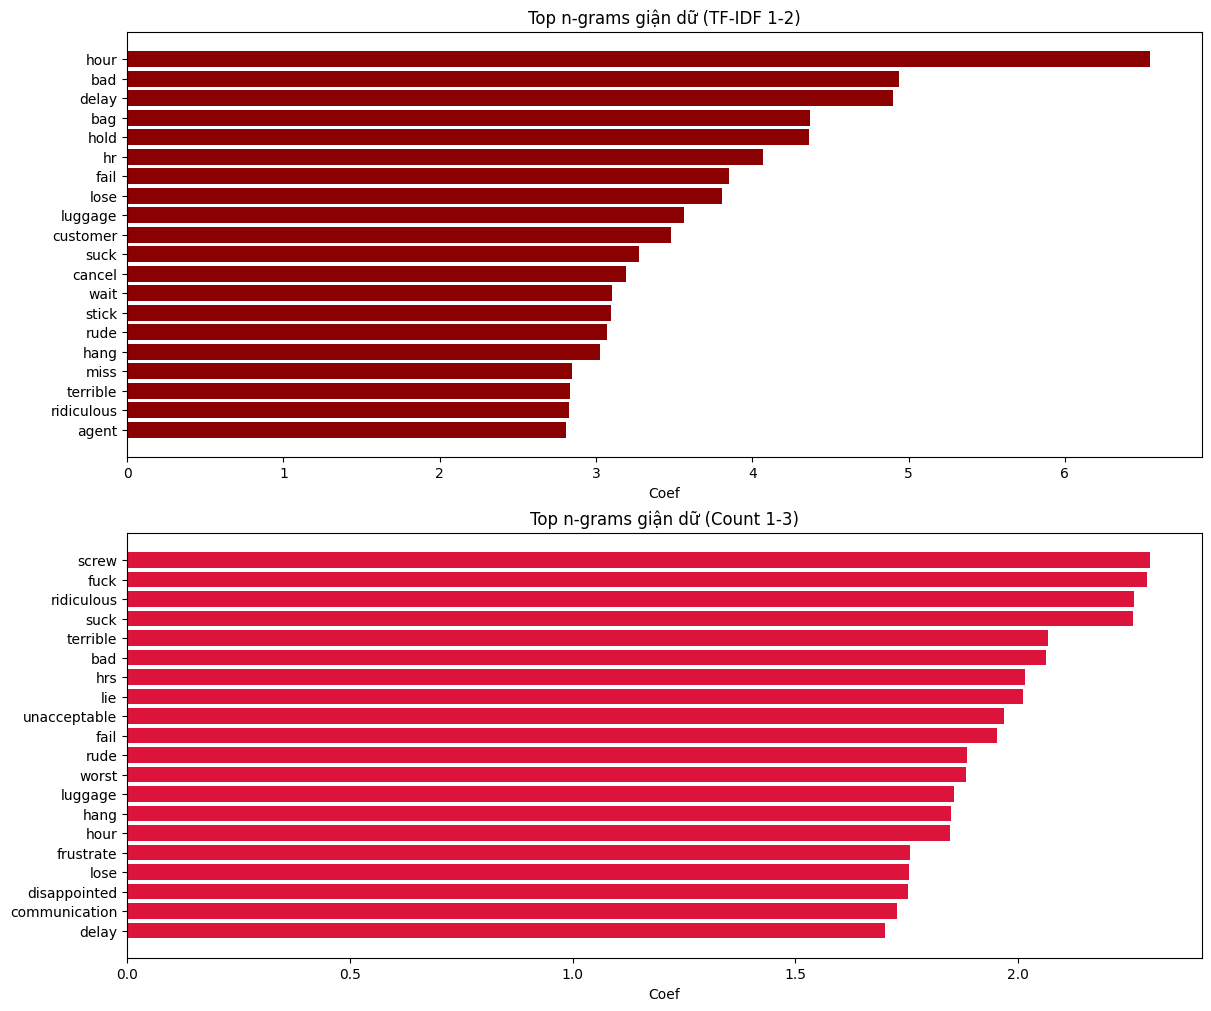

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Hàm hỗ trợ train & in top ngrams
def extract_ngrams_insight(X, y, vectorizer, topn=15):
    pipe = Pipeline([
        ('vect', vectorizer),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])
    pipe.fit(X, y)
    if hasattr(pipe.named_steps['clf'], 'coef_'):
        coef = pipe.named_steps['clf'].coef_[0]
        names = np.array(pipe.named_steps['vect'].get_feature_names_out())
        coef_df = pd.DataFrame({'ngram': names, 'coef': coef})
        top_negative = coef_df.sort_values('coef', ascending=False).head(topn)
        top_positive = coef_df.sort_values('coef', ascending=True).head(topn)
        return pipe, top_negative, top_positive
    return pipe, None, None

# 1. So sánh theo airline (định nghĩa A vs B): lọc mỗi airline và trích ra ngrams tiêu biểu
for airline in df['airline'].unique():
    print(f"\n=== Airline: {airline} ===")
    df_sub = df[df['airline'] == airline]
    X_sub = df_sub[text_col].fillna('')
    y_sub = (df_sub['airline_sentiment'] == 'negative').astype(int)
    if y_sub.nunique() < 2 or len(df_sub) < 50:
        print('Không đủ dữ liệu để huấn luyện.')
        continue

    _, top_neg, top_pos = extract_ngrams_insight(X_sub, y_sub, CountVectorizer(ngram_range=(1,2), max_features=8000, stop_words='english'), topn=10)
    print('Top n-grams liên quan giận dữ:', top_neg['ngram'].tolist())
    print('Top n-grams không giận:', top_pos['ngram'].tolist())

# 2. Dùng TF-IDF thay Count (ngram range 1-2) trên toàn bộ dataset
print('\n=== TF-IDF ngram 1-2 (toàn bộ dataset) ===')
_, top_neg_tfidf, top_pos_tfidf = extract_ngrams_insight(X, y, TfidfVectorizer(ngram_range=(1,2), max_features=15000, stop_words='english'), topn=20)
print('Top n-grams giận dữ (TF-IDF):')
print(top_neg_tfidf[['ngram','coef']])
print('Top n-grams không giận (TF-IDF):')
print(top_pos_tfidf[['ngram','coef']])

# 3. Mở rộng ngram đến 3-grams (CountVectorizer + Logistic Regression)
print('\n=== CountVectorizer ngram 1-3 (toàn bộ dataset) ===')
_, top_neg_13, top_pos_13 = extract_ngrams_insight(X, y, CountVectorizer(ngram_range=(1,3), max_features=15000, stop_words='english'), topn=20)
print('Top n-grams giận dữ (1-3):')
print(top_neg_13[['ngram','coef']])
print('Top n-grams không giận (1-3):')
print(top_pos_13[['ngram','coef']])

# Vẽ kết quả comparison cho TF-IDF và 1-3 ngrams để xem nhanh
fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)
axes[0].barh(top_neg_tfidf['ngram'][::-1], top_neg_tfidf['coef'][::-1], color='darkred')
axes[0].set_title('Top n-grams giận dữ (TF-IDF 1-2)')
axes[0].set_xlabel('Coef')
axes[1].barh(top_neg_13['ngram'][::-1], top_neg_13['coef'][::-1], color='crimson')
axes[1].set_title('Top n-grams giận dữ (Count 1-3)')
axes[1].set_xlabel('Coef')
plt.show()

### Time-series analysis: detect negative-tweet spikes by date

Parsing tweet_created and computing daily negative tweet counts...
No strong z-score spikes found (z>3). Reporting top absolute days instead.

Summary: daily negative tweets (showing tail)
tweet_created_dt
2015-02-16 00:00:00-08:00       3
2015-02-17 00:00:00-08:00     838
2015-02-18 00:00:00-08:00     736
2015-02-19 00:00:00-08:00     751
2015-02-20 00:00:00-08:00     835
2015-02-21 00:00:00-08:00    1049
2015-02-22 00:00:00-08:00    2266
2015-02-23 00:00:00-08:00    1919
2015-02-24 00:00:00-08:00     781
Freq: D, Name: tweet_id, dtype: int64

Detected spike days (z>3):
Series([], Freq: D, Name: tweet_id, dtype: float64)

Top spike days (by count):
tweet_created_dt
2015-02-22 00:00:00-08:00    2266
2015-02-23 00:00:00-08:00    1919
2015-02-21 00:00:00-08:00    1049
2015-02-17 00:00:00-08:00     838
2015-02-20 00:00:00-08:00     835
2015-02-24 00:00:00-08:00     781
2015-02-19 00:00:00-08:00     751
2015-02-18 00:00:00-08:00     736
2015-02-16 00:00:00-08:00       3
Name: tweet_id, dty

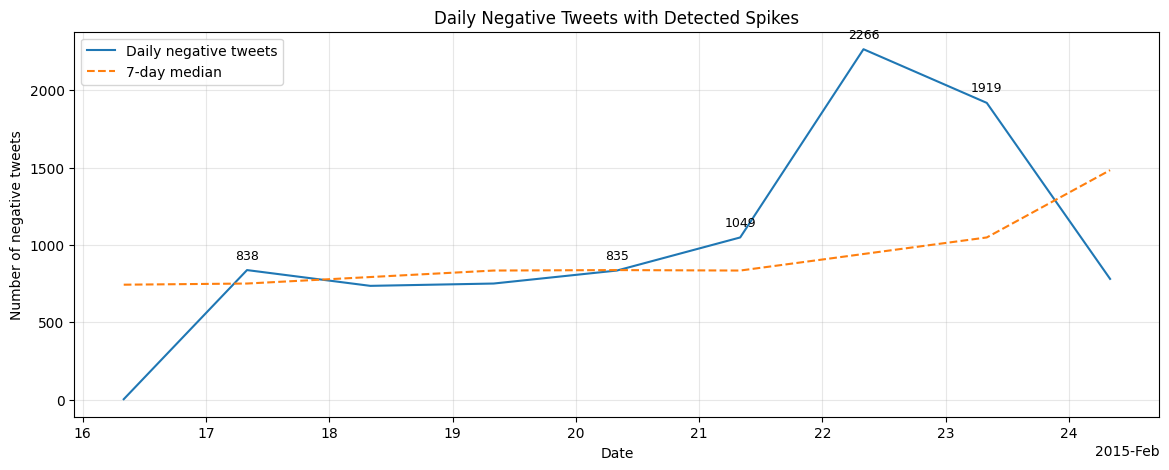


Sample tweets from top spike days:

=== 2015-02-22 — 2266 negative tweets ===
- use another browser a brand with a reputation build on tech response do not have a cross browser compatible website
- and now the flight flight book problem site be totally down folk what be the problem
- i like the customer service but a min delay just for connect passenger seem too long va
- i need to change my flight that be schedule in hour and min wait time on phone i be call intern help
- you be fail your customer because your check in process do not link to tsa pre check

=== 2015-02-23 — 1919 negative tweets ===
- hi i just bked a cool birthday trip with you but i can not add my elevate no because i enter my middle name during flight book problem crying_face
- help leave expensive headphone on flight iad to lax today seat a no one answer l f number at lax
- await my return phone call just would prefer to use your online self service option
- your chat support be not work on your site
- hey first ti

In [32]:
# Parse datetimes, compute daily negative tweet counts, detect spikes (z > 3 vs 7-day median)
print('Parsing tweet_created and computing daily negative tweet counts...')

df['tweet_created_dt'] = pd.to_datetime(df['tweet_created'], errors='coerce')
neg = df[df['airline_sentiment'] == 'negative'].copy()
neg = neg.dropna(subset=['tweet_created_dt'])
neg.set_index('tweet_created_dt', inplace=True)

daily = neg['tweet_id'].resample('D').count()
# ensure full date range (fills zeros for missing days)
daily = daily.asfreq('D', fill_value=0)

# Rolling baseline (7-day median) and std for robust z-score
rolling_median = daily.rolling(window=7, min_periods=1, center=True).median()
rolling_std = daily.rolling(window=7, min_periods=1, center=True).std().fillna(0)

# z-score against median baseline
z = (daily - rolling_median) / rolling_std.replace(0, np.nan)
spike_series = z[z > 3].dropna()

# If no z>3 spikes detected, also report top days by absolute count
if spike_series.empty:
    print('No strong z-score spikes found (z>3). Reporting top absolute days instead.')
    top_spikes = daily.nlargest(10)
else:
    top_spikes = daily.loc[spike_series.index].sort_values(ascending=False)

# Print summary
print('\nSummary: daily negative tweets (showing tail)')
print(daily.tail(10))

print('\nDetected spike days (z>3):')
print(spike_series.sort_values(ascending=False).head(20))

print('\nTop spike days (by count):')
print(top_spikes.head(20))

# Plot daily counts, baseline, and spikes
import matplotlib.dates as mdates
plt.figure(figsize=(14,5))
plt.plot(daily.index, daily.values, label='Daily negative tweets', color='tab:blue')
plt.plot(rolling_median.index, rolling_median.values, label='7-day median', linestyle='--', color='tab:orange')
if not spike_series.empty:
    plt.scatter(spike_series.index, daily.loc[spike_series.index], color='red', label='Spikes (z>3)', zorder=5)

# annotate top spike day
for dt, val in top_spikes.head(5).items():
    plt.annotate(f'{val}', xy=(pd.to_datetime(dt), val), xytext=(0,8), textcoords='offset points', ha='center', fontsize=9)

plt.title('Daily Negative Tweets with Detected Spikes')
plt.xlabel('Date')
plt.ylabel('Number of negative tweets')
plt.legend()
plt.grid(alpha=0.3)
# prettier x-axis formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()

# Show sample tweets for top spike days to help identify cause
print('\nSample tweets from top spike days:')
for dt in top_spikes.head(5).index:
    day = pd.to_datetime(dt).date()
    subset = neg[neg.index.date == day]
    print(f"\n=== {day} — {len(subset)} negative tweets ===")
    # prefer `text_preprocessed` if available, else `text`
    text_col_pref = 'text_preprocessed' if 'text_preprocessed' in subset.columns else 'text'
    samples = subset[text_col_pref].dropna().head(5).tolist()
    for s in samples:
        print('-', s)
    if len(samples) == 0:
        print('  (no text available)')

# End of time-series spike analysis cell

### Expanded spike analysis: per-airline spikes, hourly breakdown for top days, and export CSV

Running expanded spike analysis (per-airline, hourly, export)...
Spike summary saved to ../data/spike_summary_by_airline.csv


,airline,date,count,z
2,American,2015-02-24,369,NaN
0,American,2015-02-23,826,NaN
13,United,2015-02-23,449,NaN
10,US Airways,2015-02-23,372,NaN
5,Delta,2015-02-23,125,NaN
16,Virgin America,2015-02-23,31,NaN
1,American,2015-02-22,762,NaN
9,US Airways,2015-02-22,561,NaN
12,United,2015-02-22,532,NaN
3,Delta,2015-02-22,255,NaN



Top overall negative days:
tweet_created_dt
2015-02-22 00:00:00-08:00    2266
2015-02-23 00:00:00-08:00    1919
2015-02-21 00:00:00-08:00    1049
Name: tweet_id, dtype: int64


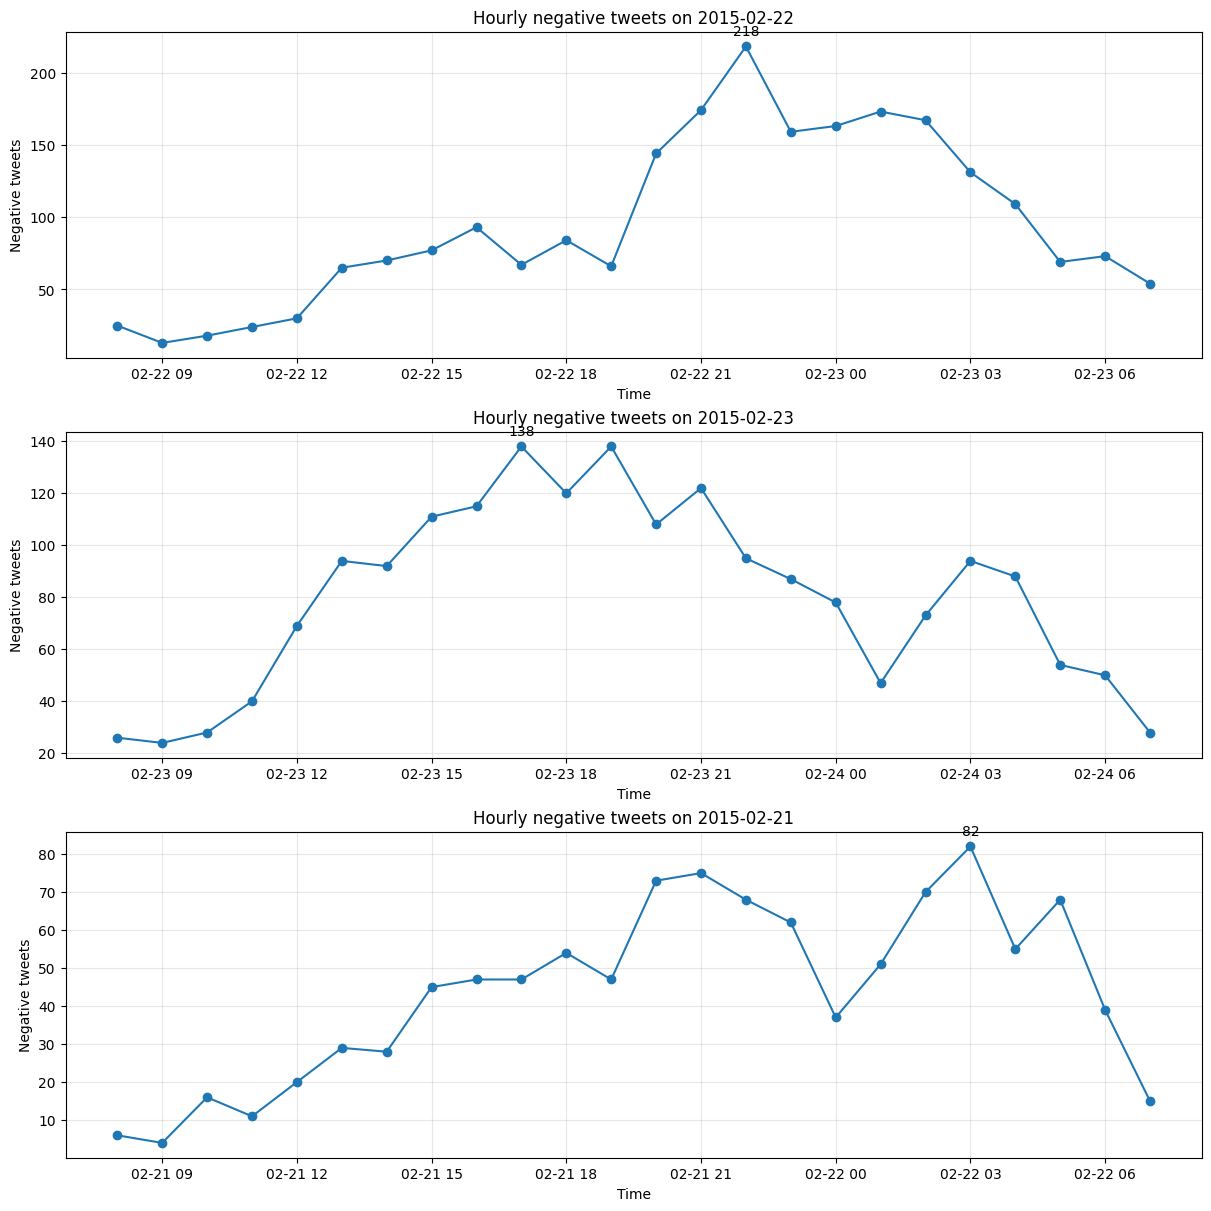

Overall top spike days saved to ../data/top_spike_days_overall.csv

Sample tweets for airline-specific spike days:

=== American — 2015-02-23 (1919 negative tweets) ===
- hi i just bked a cool birthday trip with you but i can not add my elevate no because i enter my middle name during flight book problem crying_face
- help leave expensive headphone on flight iad to lax today seat a no one answer l f number at lax
- await my return phone call just would prefer to use your online self service option
- your chat support be not work on your site
- hey first time flyer next week excite but i be have a hard time get my flight add to my elevate account help

=== Delta — 2015-02-22 (2266 negative tweets) ===
- use another browser a brand with a reputation build on tech response do not have a cross browser compatible website
- and now the flight flight book problem site be totally down folk what be the problem
- i like the customer service but a min delay just for connect passenger seem too lon

In [34]:
import os
print('Running expanded spike analysis (per-airline, hourly, export)...')

# ensure tweet_created_dt exists
df['tweet_created_dt'] = pd.to_datetime(df['tweet_created'], errors='coerce')

spike_rows = []

for airline in sorted(df['airline'].dropna().unique()):
    sub = df[df['airline'] == airline].copy()
    sub['tweet_created_dt'] = pd.to_datetime(sub['tweet_created'], errors='coerce')
    sub_neg = sub[sub['airline_sentiment'] == 'negative'].dropna(subset=['tweet_created_dt'])
    if len(sub_neg) < 10:
        print(f'Skipping {airline}: too few negative tweets ({len(sub_neg)})')
        continue

    daily = sub_neg.set_index('tweet_created_dt')['tweet_id'].resample('D').count().asfreq('D', fill_value=0)
    rolling_median = daily.rolling(window=7, min_periods=1, center=True).median()
    rolling_std = daily.rolling(window=7, min_periods=1, center=True).std().fillna(0)
    z = (daily - rolling_median) / rolling_std.replace(0, np.nan)

    # define spikes
    spikes = z[z > 3]
    if spikes.empty:
        # fallback: top 3 absolute days for this airline
        top_days = daily.nlargest(3)
        for dt, cnt in top_days.items():
            spike_rows.append({'airline': airline, 'date': pd.to_datetime(dt).date(), 'count': int(cnt), 'z': float('nan')})
    else:
        for dt, zval in spikes.items():
            spike_rows.append({'airline': airline, 'date': pd.to_datetime(dt).date(), 'count': int(daily.loc[dt]), 'z': float(zval)})

# create summary DataFrame and save
spike_summary = pd.DataFrame(spike_rows)
if spike_summary.empty:
    print('No airline-specific spikes found.')
else:
    spike_summary = spike_summary.sort_values(['date','count'], ascending=[False, False])
    out_csv = '../data/spike_summary_by_airline.csv'
    spike_summary.to_csv(out_csv, index=False)
    print(f'Spike summary saved to {out_csv}')
    display(spike_summary.head(50))

# Hourly breakdown for top overall spike days (use previously computed daily from negative global data)
neg_all = df[df['airline_sentiment'] == 'negative'].copy()
neg_all = neg_all.dropna(subset=['tweet_created_dt'])
neg_all.set_index('tweet_created_dt', inplace=True)

daily_all = neg_all['tweet_id'].resample('D').count().asfreq('D', fill_value=0)

# choose top 3 days overall
top_overall = daily_all.nlargest(3)
print('\nTop overall negative days:')
print(top_overall)

# plot hourly for each top day
import math
top_days = [pd.to_datetime(idx).date() for idx in top_overall.index]
fig, axes = plt.subplots(len(top_days), 1, figsize=(12, 4 * len(top_days)), constrained_layout=True)
if len(top_days) == 1:
    axes = [axes]

for ax, day in zip(axes, top_days):
    # Use date-based selection to avoid tz-aware vs tz-naive comparison issues
    subset_day = neg_all[neg_all.index.date == day]
    if subset_day.empty:
        hourly = pd.Series(0, index=pd.date_range(start=pd.Timestamp(day), periods=24, freq='h'))
    else:
        # Resample hourly — make index tz-naive for consistent resampling
        idx = subset_day.index
        if getattr(idx, 'tz', None) is not None:
            # convert to UTC then remove tz info
            subset_day = subset_day.tz_convert('UTC')
            subset_day.index = subset_day.index.tz_localize(None)
        hourly = subset_day['tweet_id'].resample('h').count().asfreq('h', fill_value=0)

    ax.plot(hourly.index, hourly.values, marker='o')
    ax.set_title(f'Hourly negative tweets on {day}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Negative tweets')
    ax.grid(alpha=0.3)
    # annotate peak hour
    if len(hourly) > 0:
        peak_idx = hourly.idxmax()
        peak_val = int(hourly.max())
        if peak_val > 0:
            ax.annotate(f'{peak_val}', xy=(peak_idx, peak_val), xytext=(0,8), textcoords='offset points', ha='center')

plt.show()

# Save top overall days to CSV for external comparison (C)
out_overall = '../data/top_spike_days_overall.csv'
top_overall_df = top_overall.reset_index()
top_overall_df.columns = ['date','count']
# convert date to date-only
top_overall_df['date'] = top_overall_df['date'].dt.date
top_overall_df.to_csv(out_overall, index=False)
print(f'Overall top spike days saved to {out_overall}')

# Provide samples for each airline top spike day from spike_summary
if not spike_summary.empty:
    print('\nSample tweets for airline-specific spike days:')
    grouped = spike_summary.groupby('airline')
    for airline, group in grouped:
        top = group.sort_values('count', ascending=False).head(1).iloc[0]
        day = pd.to_datetime(top['date']).date()
        subset = neg_all[neg_all.index.date == day]
        print(f"\n=== {airline} — {day} ({len(subset)} negative tweets) ===")
        text_col_pref = 'text_preprocessed' if 'text_preprocessed' in df.columns else 'text'
        for s in subset[text_col_pref].dropna().head(5).tolist():
            print('-', s)

print('\nExpanded spike analysis complete.')

### Compare spikes across selected airlines (side-by-side daily + hourly for top spike day)

Top airlines to compare: ['United', 'US Airways', 'American']


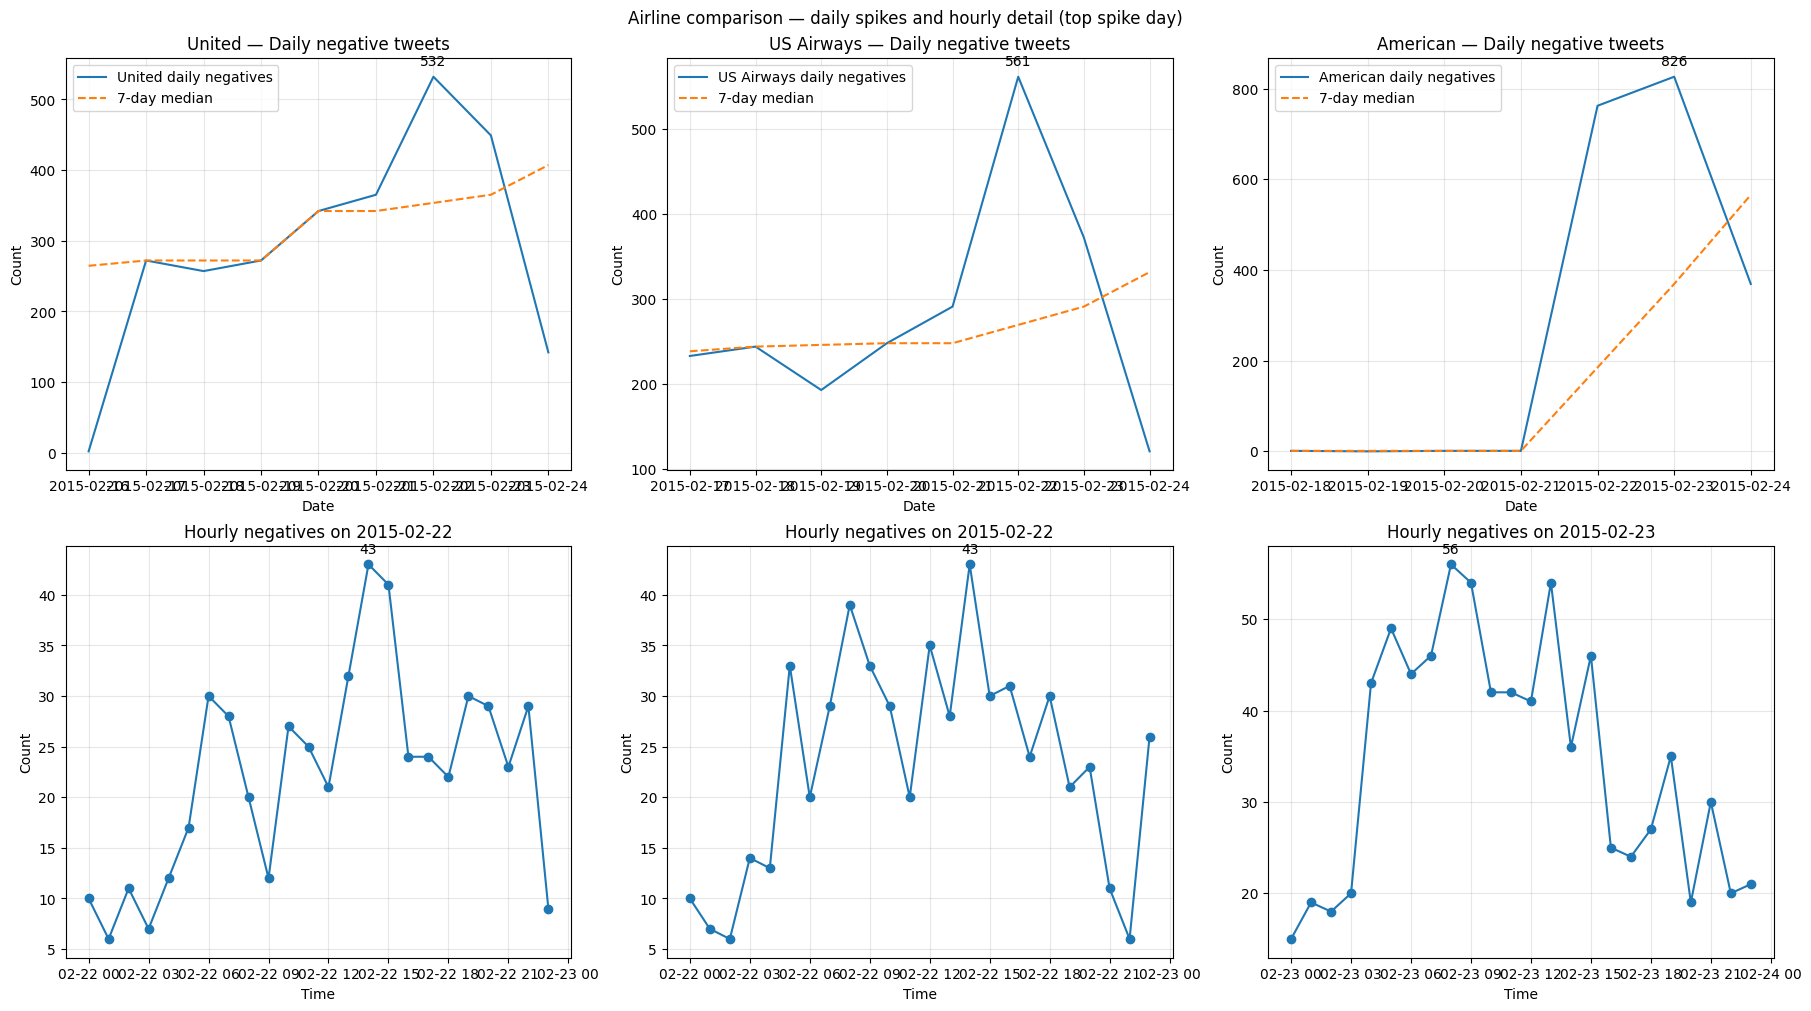

In [36]:
# choose top 3 airlines by negative volume (from sentiment_by_airline computed earlier)
neg_counts = df[df['airline_sentiment']=='negative']['airline'].value_counts()
top_airlines = neg_counts.nlargest(3).index.tolist()
print('Top airlines to compare:', top_airlines)

# Prepare figure: 2 rows (daily, hourly) x N cols (airlines)
n = len(top_airlines)
fig, axes = plt.subplots(2, n, figsize=(6*n, 10), constrained_layout=True)
if n == 1:
    axes = axes.reshape(2,1)

for col, airline in enumerate(top_airlines):
    sub = df[df['airline'] == airline].copy()
    sub['tweet_created_dt'] = pd.to_datetime(sub['tweet_created'], errors='coerce')
    sub_neg = sub[sub['airline_sentiment'] == 'negative'].dropna(subset=['tweet_created_dt'])
    if sub_neg.empty:
        axes[0, col].text(0.5, 0.5, 'No data', ha='center')
        axes[1, col].text(0.5, 0.5, 'No data', ha='center')
        continue

    # daily time series and spikes
    daily = sub_neg.set_index('tweet_created_dt')['tweet_id'].resample('D').count().asfreq('D', fill_value=0)
    rm = daily.rolling(window=7, min_periods=1, center=True).median()
    rs = daily.rolling(window=7, min_periods=1, center=True).std().fillna(0)
    z = (daily - rm) / rs.replace(0, np.nan)
    spikes = z[z > 3]
    if spikes.empty:
        top_day = daily.idxmax()
    else:
        top_day = spikes.index[0]

    # Plot daily
    ax = axes[0, col]
    ax.plot(daily.index, daily.values, label=f'{airline} daily negatives', color='tab:blue')
    ax.plot(rm.index, rm.values, linestyle='--', color='tab:orange', label='7-day median')
    if not spikes.empty:
        ax.scatter(spikes.index, daily.loc[spikes.index], color='red', zorder=5, label='spikes (z>3)')
    ax.set_title(f'{airline} — Daily negative tweets')
    ax.set_xlabel('Date')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
    ax.legend()
    # annotate top day
    try:
        top_val = int(daily.loc[top_day])
        ax.annotate(f'{top_val}', xy=(pd.to_datetime(top_day), top_val), xytext=(0,8), textcoords='offset points', ha='center')
    except Exception:
        pass

    # hourly plot for the top day
    ax2 = axes[1, col]
    day = pd.to_datetime(top_day)
    # select timezone-aware safely: compare dates
    day_date = day.date()
    subset_day = sub_neg[sub_neg['tweet_created_dt'].dt.date == day_date].copy()
    if subset_day.empty:
        ax2.text(0.5, 0.5, 'No hourly data', ha='center')
    else:
        idx = subset_day['tweet_created_dt']
        # normalize tz if present
        if getattr(idx.dt.tz, 'zone', None) is not None:
            subset_day['tweet_created_dt'] = subset_day['tweet_created_dt'].dt.tz_convert('UTC').dt.tz_localize(None)
        subset_day = subset_day.set_index('tweet_created_dt')
        hourly = subset_day['tweet_id'].resample('h').count().asfreq('h', fill_value=0)
        ax2.plot(hourly.index, hourly.values, marker='o')
        ax2.set_title(f'Hourly negatives on {day_date}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Count')
        ax2.grid(alpha=0.3)
        # annotate peak
        peak = int(hourly.max())
        if peak > 0:
            ax2.annotate(f'{peak}', xy=(hourly.idxmax(), peak), xytext=(0,8), textcoords='offset points', ha='center')

plt.suptitle('Airline comparison — daily spikes and hourly detail (top spike day)')
plt.show()

### Compare retweet_count across sentiment groups and show viral negative tweets



Retweet count summary by sentiment:
                   count      mean  median       std
airline_sentiment                                   
negative            9178  0.093375     0.0  0.792865
neutral             3099  0.060987     0.0  0.658037
positive            2363  0.069403     0.0  0.659914

Log1p retweet stats by sentiment:
                       mean  median       std  count
airline_sentiment                                   
negative           0.050902     0.0  0.209118   9178
neutral            0.028327     0.0  0.178533   3099
positive           0.030960     0.0  0.192630   2363
Kruskal-Wallis H-test: H=77.539, p=1.45e-17


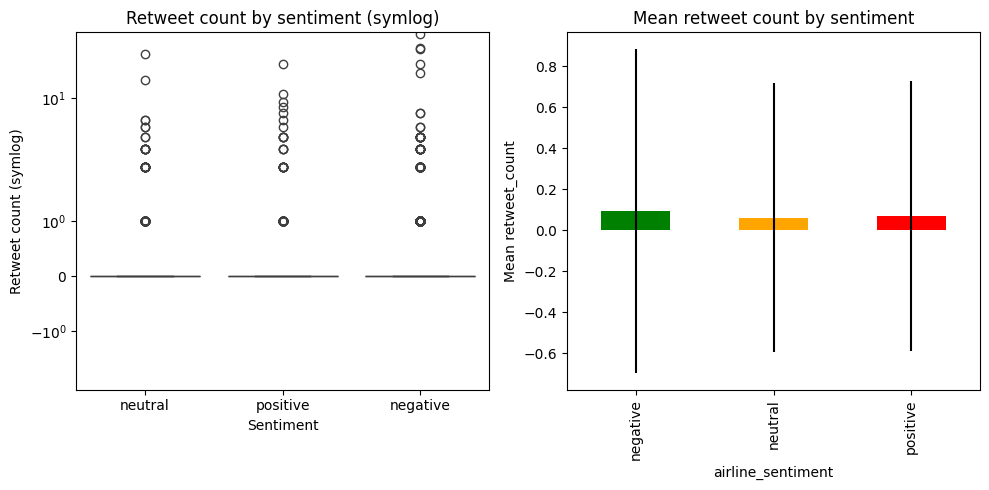


Top viral negative tweets (by retweet_count):

Retweets: 44, Airline: US Airways, Date: 2015-02-17 20:06:21 -0800
- @USAirways 5 hr flight delay and a delay when we land . Is that even real life ? Get me off this plane , I wanna go home 👠👠👠 (3 heel clicks)

Retweets: 32, Airline: US Airways, Date: 2015-02-17 20:50:56 -0800
- @USAirways of course never again tho . Thanks for tweetin ur concern but not Doin anythin to fix what happened. I'll choose wiser next time

Retweets: 31, Airline: Delta, Date: 2015-02-23 10:30:29 -0800
- STOP. USING.THIS.WORD. IF. YOU'RE. A. COMPANY. RT @JetBlue: Our fleet's on fleek. http://t.co/Fd2TNYcTrB

Retweets: 22, Airline: Delta, Date: 2015-02-23 10:51:54 -0800
- can you not? RT @JetBlue Our fleet's on fleek. http://t.co/413GiAL0yl

Retweets: 18, Airline: Delta, Date: 2015-02-23 12:04:21 -0800
- Just in case you needed confirmation that "on fleek" is dead &amp; gone. RT @JetBlue: Our fleet's on fleek. http://t.co/G4O6yX7TMJ

Retweets: 7, Airline: Delta, D

In [42]:
# Ensure retweet_count exists and is numeric
df['retweet_count'] = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0).astype(int)

groups = df.groupby('airline_sentiment')['retweet_count'].agg(['count','mean','median','std'])
print('\nRetweet count summary by sentiment:')
print(groups)

# Also compute mean and median with log1p transform to handle skew
df['retweet_log1p'] = np.log1p(df['retweet_count'])
log_stats = df.groupby('airline_sentiment')['retweet_log1p'].agg(['mean','median','std','count'])
print('\nLog1p retweet stats by sentiment:')
print(log_stats)

# Statistical test (Kruskal-Wallis non-parametric)
from scipy.stats import kruskal
neg = df[df['airline_sentiment']=='negative']['retweet_count']
neut = df[df['airline_sentiment']=='neutral']['retweet_count']
pos = df[df['airline_sentiment']=='positive']['retweet_count']

try:
    stat, p = kruskal(neg, neut, pos)
    print(f'Kruskal-Wallis H-test: H={stat:.3f}, p={p:.3g}')
except Exception as e:
    print('Kruskal-Wallis test failed:', e)

# Visualization: boxplot (log scale) and bar of means
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='airline_sentiment', y='retweet_count')
plt.yscale('symlog')
plt.title('Retweet count by sentiment (symlog)')
plt.xlabel('Sentiment')
plt.ylabel('Retweet count (symlog)')

plt.subplot(1,2,2)
means = df.groupby('airline_sentiment')['retweet_count'].mean()
stds = df.groupby('airline_sentiment')['retweet_count'].std()
means.plot(kind='bar', yerr=stds, color=['green','orange','red'])
plt.title('Mean retweet count by sentiment')
plt.ylabel('Mean retweet_count')
plt.tight_layout()
plt.show()

# Show top viral negative tweets
print('\nTop viral negative tweets (by retweet_count):')
neg_sorted = df[df['airline_sentiment']=='negative'].sort_values('retweet_count', ascending=False)
for _, row in neg_sorted.head(10).iterrows():
    print(f"\nRetweets: {row['retweet_count']}, Airline: {row.get('airline','')}, Date: {row.get('tweet_created','')}")
    text_col_pref = 'text' if 'text' in row.index else df.columns[0]
    print('-', row.get(text_col_pref, '')[:300])

# Save summary to CSV
out_csv = '../data/retweet_summary_by_sentiment.csv'
groups.to_csv(out_csv)
print(f'Grouped retweet summary saved to {out_csv}')

# Xây dựng mô hình dự đoán

In [74]:
X = df['text_preprocessed']
y = df['airline_sentiment']

###  Chia dữ liệu

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### TF-IDF

In [77]:
tfid = TfidfVectorizer(ngram_range=(1, 2))
tfid


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

## Huấn luyện mô hình trước khi xử lý mất cân bằng

In [91]:
X_train_idf = tfid.fit_transform(X_train)
X_test_idf = tfid.transform(X_test)

print(f"Training set size: {X_train_idf.shape[0]}")
print(f"Test set size: {X_test_idf.shape[0]}")
print(f"TF-IDF train shape: {X_train_idf.shape}")
print(f"TF-IDF test shape: {X_test_idf.shape}")
print("\nPhân bố nhãn trong training set:")
print(pd.Series(y_train).value_counts().sort_index())


Training set size: 11712
Test set size: 2928
TF-IDF train shape: (11712, 74399)
TF-IDF test shape: (2928, 74399)

Phân bố nhãn trong training set:
airline_sentiment
negative    7343
neutral     2479
positive    1890
Name: count, dtype: int64


In [86]:
sentiment_order = ["negative", "neutral", "positive"]

### Train Random Forest: Nguyên bản

In [ ]:
rf_original = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_original.fit(X_train_idf, y_train)

# Predict và tính F1 score
y_pred_rf = rf_original.predict(X_test_idf)
f1_rf_original = f1_score(y_pred_rf, y_test, average='macro')

print(f"Random Forest (nguyên bản) - Macro F1 Score: {f1_rf_original:.4f}")
print(classification_report(y_test, y_pred_rf, 
                           target_names=sentiment_order))

Random Forest (nguyên bản) - Macro F1 Score: 0.7335
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      1835
     neutral       0.61      0.68      0.64       620
    positive       0.72      0.68      0.70       473

    accuracy                           0.79      2928
   macro avg       0.73      0.74      0.73      2928
weighted avg       0.79      0.79      0.79      2928



### Train Logistic Regression: nguyên bản

In [ ]:
lr_original = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
lr_original.fit(X_train_idf, y_train)

# Predict và tính F1 score
y_pred_lr = lr_original.predict(X_test_idf)
f1_lr_original = f1_score(y_pred_lr, y_test, average='macro')

print(f"Logistic Regression (nguyên bản) - Macro F1 Score: {f1_lr_original:.4f}")
print(classification_report(y_test, y_pred_lr, 
                           target_names=sentiment_order))

Logistic Regression (nguyên bản) - Macro F1 Score: 0.7579
              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      1835
     neutral       0.65      0.69      0.67       620
    positive       0.74      0.69      0.72       473

    accuracy                           0.81      2928
   macro avg       0.76      0.76      0.76      2928
weighted avg       0.81      0.81      0.81      2928



### Confusion Matrices: nguyên bản

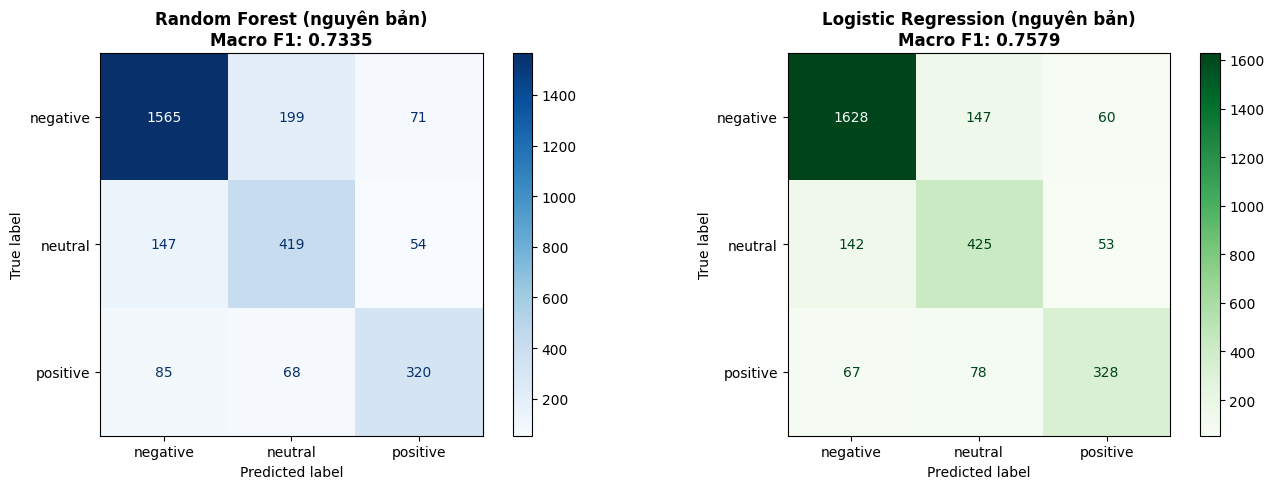

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf_orig = confusion_matrix(y_test, y_pred_rf, labels=sentiment_order)
disp_rf_orig = ConfusionMatrixDisplay(confusion_matrix=cm_rf_orig, display_labels=sentiment_order)
disp_rf_orig.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (nguyên bản)\nMacro F1: {f1_rf_original:.4f}", fontweight='bold')

# Logistic Regression
cm_lr_orig = confusion_matrix(y_test, y_pred_lr, labels=sentiment_order)
disp_lr_orig = ConfusionMatrixDisplay(confusion_matrix=cm_lr_orig, display_labels=sentiment_order)
disp_lr_orig.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (nguyên bản)\nMacro F1: {f1_lr_original:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

## Huấn luyện mô hình sau khi xử lý cân bằng bằng `RandomOver-sampling` 

In [ ]:
ros = RandomOverSampler(
    sampling_strategy='auto',
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(X_train_idf, y_train)
X_test_ros, y_test_ros = X_test_idf, y_test

print("Phân bố nhãn sau oversampling:")
print(pd.Series(y_train_ros).value_counts().sort_index())


Phân bố nhãn sau oversampling:
airline_sentiment
negative    7343
neutral     7343
positive    7343
Name: count, dtype: int64


### Train Random Forest: RandomOver-sampling

In [ ]:
rf_ros = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_ros.fit(X_train_ros, y_train_ros)

# Predict và tính F1 score
y_pred_rf_ros = rf_ros.predict(X_test_ros)
macro_f1_score_random_forest_over = f1_score(y_pred_rf_ros, y_test_ros, average='macro')

print(f"Random Forest (Sau RandomOver-sampling) - Macro F1 Score: {macro_f1_score_random_forest_over:.4f}")
print(classification_report(y_test_ros, y_pred_rf_ros, 
                           target_names=sentiment_order))

Random Forest (Sau RandomOver-sampling) - Macro F1 Score: 0.7238
              precision    recall  f1-score   support

    negative       0.84      0.90      0.87      1835
     neutral       0.65      0.61      0.63       620
    positive       0.75      0.61      0.67       473

    accuracy                           0.79      2928
   macro avg       0.75      0.71      0.72      2928
weighted avg       0.79      0.79      0.79      2928



### Train Logistic Regression: RandomOver-sampling

In [ ]:
lr_ros = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
lr_ros.fit(X_train_ros, y_train_ros)

# Predict và tính F1 score
y_pred_lr_ros = lr_ros.predict(X_test_ros)
macro_f1_score_logistic_regression_over = f1_score(y_pred_lr_ros, y_test_ros, average='macro')

print(f"Logistic Regression (Sau RandomOver-sampling) - Macro F1 Score: {macro_f1_score_logistic_regression_over:.4f}")
print(classification_report(y_test_ros, y_pred_lr_ros, 
                           target_names=sentiment_order))

Logistic Regression (Sau RandomOver-sampling) - Macro F1 Score: 0.7576
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      1835
     neutral       0.67      0.66      0.67       620
    positive       0.75      0.69      0.72       473

    accuracy                           0.82      2928
   macro avg       0.77      0.75      0.76      2928
weighted avg       0.81      0.82      0.81      2928



### Confusion Matrices: RandomOver-sampling

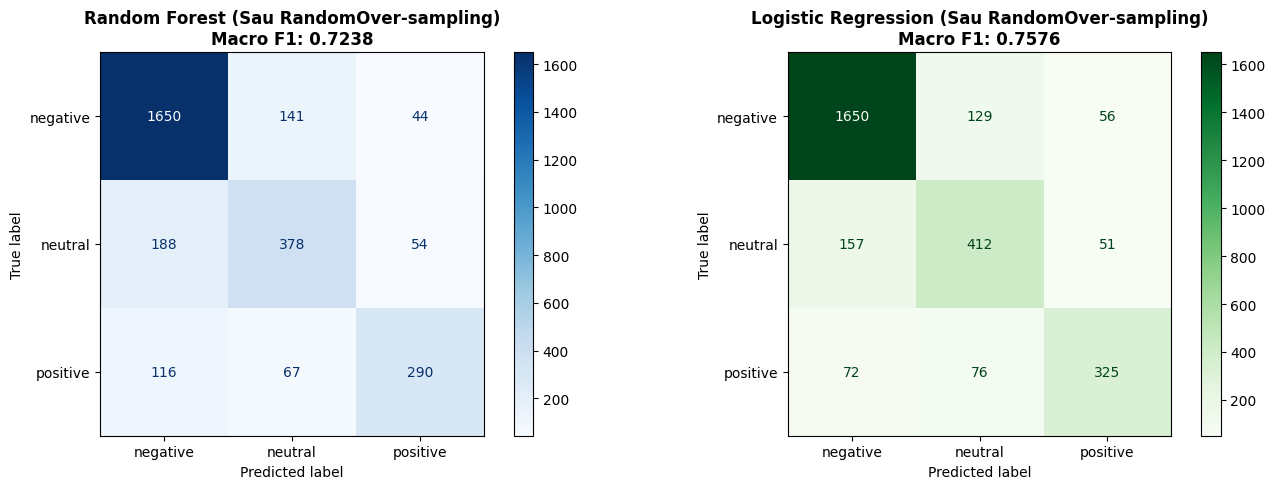

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test_ros, y_pred_rf_ros, labels=sentiment_order)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sentiment_order)
disp_rf.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Sau RandomOver-sampling)\nMacro F1: {macro_f1_score_random_forest_over:.4f}", fontweight='bold')

# Logistic Regression
cm_lr = confusion_matrix(y_test_ros, y_pred_lr_ros, labels=sentiment_order)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sentiment_order)
disp_lr.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Sau RandomOver-sampling)\nMacro F1: {macro_f1_score_logistic_regression_over:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

## Huấn luyện mô hình sau khi xử lý cân bằng bằng `under-sampling`

In [101]:
under_sampling = RandomUnderSampler(
    sampling_strategy='auto',
    random_state=42,
    replacement=False
)

X_train_under, y_train_under = under_sampling.fit_resample(X_train_idf, y_train)
X_test_under, y_test_under = X_test_idf, y_test

print("Phân bố nhãn sau undersampling:")
print(pd.Series(y_train_under).value_counts().sort_index())


Phân bố nhãn sau undersampling:
airline_sentiment
negative    1890
neutral     1890
positive    1890
Name: count, dtype: int64


### Train Random Forest: RandomUnder-sampling

In [103]:
random_forest_classifier_under = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
random_forest_classifier_under.fit(X_train_under, y_train_under)

random_forest_classifier_under_prediction = random_forest_classifier_under.predict(X_test_under)
macro_f1_score_random_forest_under = f1_score(random_forest_classifier_under_prediction, y_test_under, average='macro')
print(f"Random Forest (Sau Under-sampling) - Macro F1 Score: {macro_f1_score_random_forest_under:.4f}")
print(classification_report(y_test_under, random_forest_classifier_under_prediction))

Random Forest (Sau Under-sampling) - Macro F1 Score: 0.7179
              precision    recall  f1-score   support

    negative       0.89      0.79      0.84      1835
     neutral       0.57      0.71      0.63       620
    positive       0.65      0.71      0.68       473

    accuracy                           0.76      2928
   macro avg       0.70      0.74      0.72      2928
weighted avg       0.78      0.76      0.77      2928



### Train Logistic Regression: RandomUder-sampling

In [104]:
logistic_regression_under = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
logistic_regression_under.fit(X_train_under, y_train_under)

logistic_regression_under_prediction = logistic_regression_under.predict(X_test_under)
macro_f1_score_logistic_regression_under = f1_score(logistic_regression_under_prediction, y_test_under, average='macro')
print(f"Logistic Regression (Sau Under-sampling) - Macro F1 Score: {macro_f1_score_logistic_regression_under:.4f}")
print(classification_report(y_test_under, logistic_regression_under_prediction))

Logistic Regression (Sau Under-sampling) - Macro F1 Score: 0.7385
              precision    recall  f1-score   support

    negative       0.90      0.83      0.86      1835
     neutral       0.60      0.70      0.64       620
    positive       0.69      0.73      0.71       473

    accuracy                           0.79      2928
   macro avg       0.73      0.75      0.74      2928
weighted avg       0.80      0.79      0.79      2928



### Confusion Matrices: Under-sampling

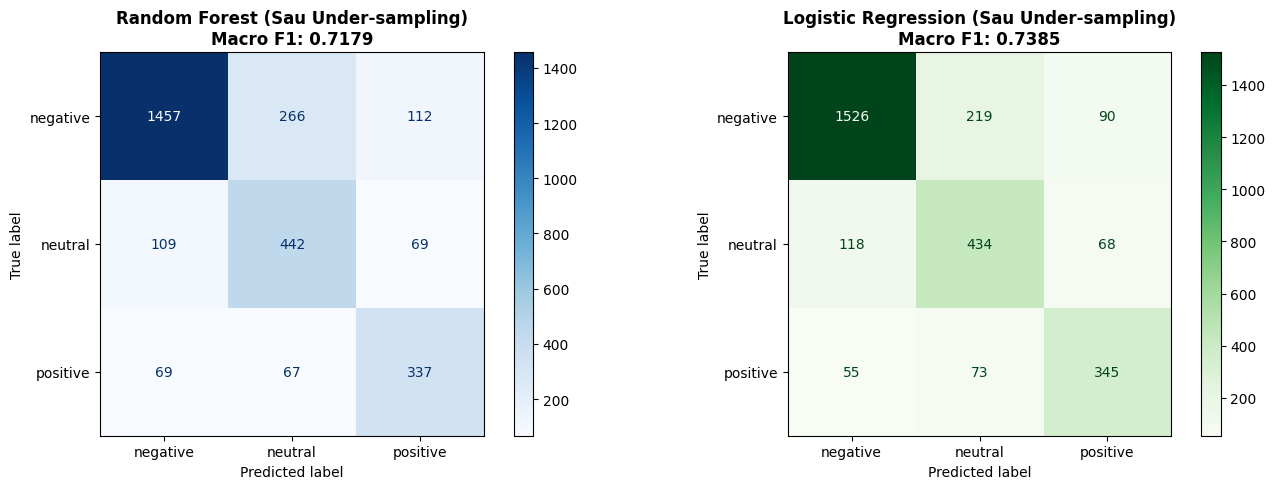

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Random Forest
cm_rf_under = confusion_matrix(y_test_under, random_forest_classifier_under_prediction, labels=sentiment_order)
disp_rf_under = ConfusionMatrixDisplay(confusion_matrix=cm_rf_under, display_labels=sentiment_order)
disp_rf_under.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Sau Under-sampling)\nMacro F1: {macro_f1_score_random_forest_under:.4f}", fontweight='bold')
# Logistic Regression
cm_lr_under = confusion_matrix(y_test_under, logistic_regression_under_prediction, labels=sentiment_order)
disp_lr_under = ConfusionMatrixDisplay(confusion_matrix=cm_lr_under, display_labels=sentiment_order)
disp_lr_under.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Sau Under-sampling)\nMacro F1: {macro_f1_score_logistic_regression_under:.4f}", fontweight='bold')
plt.tight_layout()
plt.show()

## So sánh F1 Scores giữa 3 phương pháp, xem cải thiện bao nhiêu so với nguyên bản

In [ ]:
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression'],
    'F1 (nguyên bản)': [f1_rf_original, f1_lr_original],
    'F1 (Sau Over-sampling)': [macro_f1_score_random_forest_over, macro_f1_score_logistic_regression_over],
    'F1 (Sau Under-sampling)': [macro_f1_score_random_forest_under, macro_f1_score_logistic_regression_under]
}

comparison_df = pd.DataFrame(comparison_data)
print("="*80)
print("SO SÁNH F1 SCORES GIỮA CÁC PHƯƠNG PHÁP")
print("="*80)
display(comparison_df.round(4))


SO SÁNH F1 SCORES GIỮA CÁC PHƯƠNG PHÁP


,Model,F1 (nguyên bản),F1 (Sau Over-sampling),F1 (Sau Under-sampling)
0,Random Forest,0.7335,0.7238,0.7179
1,Logistic Regression,0.7579,0.7576,0.7385


In [109]:
# Phân tích chi tiết F1-Score theo từng class
from sklearn.metrics import f1_score

# Tính F1-Score cho từng class (negative, neutral, positive) - Nguyên bản
f1_rf_per_class_orig = f1_score(y_test, y_pred_rf_original, average=None, labels=sentiment_order)
f1_lr_per_class_orig = f1_score(y_test, y_pred_lr_original, average=None, labels=sentiment_order)

# Tính F1-Score cho từng class (negative, neutral, positive) - Sau Over-sampling
f1_rf_per_class_over = f1_score(y_test_ros, y_pred_rf_ros, average=None, labels=sentiment_order)
f1_lr_per_class_over = f1_score(y_test_ros, y_pred_lr_ros, average=None, labels=sentiment_order)

# Tính F1-Score cho từng class (negative, neutral, positive) - Sau Under-sampling
f1_rf_per_class_under = f1_score(y_test_under, random_forest_classifier_under_prediction, average=None, labels=sentiment_order)
f1_lr_per_class_under = f1_score(y_test_under, logistic_regression_under_prediction, average=None, labels=sentiment_order)

# Tạo DataFrame để so sánh F1-Score theo từng class giữa 3 phương pháp
f1_comparison_df = pd.DataFrame({
    'Sentiment': sentiment_order,
    'F1 (Original) - RF': f1_rf_per_class_orig,
    'F1 (Original) - LR': f1_lr_per_class_orig,
    'F1 (Over-sampling) - RF': f1_rf_per_class_over,
    'F1 (Over-sampling) - LR': f1_lr_per_class_over,
    'F1 (Under-sampling) - RF': f1_rf_per_class_under,
    'F1 (Under-sampling) - LR': f1_lr_per_class_under
})  

print("="*80)
print("SO SÁNH F1-SCORE THEO TỪNG CLASS GIỮA CÁC PHƯƠNG PHÁP")
print("="*80)
display(f1_comparison_df.round(4))  



SO SÁNH F1-SCORE THEO TỪNG CLASS GIỮA CÁC PHƯƠNG PHÁP


,Sentiment,F1 (Original) - RF,F1 (Original) - LR,F1 (Over-sampling) - RF,F1 (Over-sampling) - LR,F1 (Under-sampling) - RF,F1 (Under-sampling) - LR
0,negative,0.8618,0.8867,0.8709,0.8885,0.8398,0.8636
1,neutral,0.6417,0.6693,0.6269,0.6661,0.6337,0.6449
2,positive,0.6972,0.7177,0.6736,0.7182,0.6801,0.7070


### Sử dụng GridSearchCV

In [117]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

# Tạo K-Fold cross validation để giữ nguyên tỉ lệ lớp (rất quan trọng với dữ liệu imbalanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 1. Tối ưu Logistic Regression
# ==========================================
print("Đang chạy GridSearchCV cho Logistic Regression...")
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid=lr_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1, # Dùng tất cả CPU core để chạy nhanh hơn
    verbose=1
)

start_time = time.time()
lr_grid.fit(X_train_idf, y_train)
print(f"Hoàn thành trong: {time.time() - start_time:.2f} giây")
print(f"Tham số LR tốt nhất: {lr_grid.best_params_}")
print(f"F1 Macro (CV) tốt nhất: {lr_grid.best_score_:.4f}\n")

# Đánh giá LR tốt nhất trên tập Test
y_pred_test = lr_grid.best_estimator_.predict(X_test_idf) 
print('Macro F1:', f1_score(y_test, y_pred_test, average='macro'))
print(classification_report(y_test, y_pred_test))


Đang chạy GridSearchCV cho Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Hoàn thành trong: 100.12 giây
Tham số LR tốt nhất: {'C': 10, 'solver': 'saga'}
F1 Macro (CV) tốt nhất: 0.7461

Macro F1: 0.7487420209250532
              precision    recall  f1-score   support

    negative       0.87      0.91      0.89      1835
     neutral       0.66      0.63      0.64       620
    positive       0.77      0.67      0.71       473

    accuracy                           0.81      2928
   macro avg       0.77      0.74      0.75      2928
weighted avg       0.81      0.81      0.81      2928



In [124]:
print("Đang chạy GridSearchCV cho Random Forest...")
rf_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    'max_depth': [5, 10, 20, 30, 40],
    # 'min_samples_leaf': [1, 2, 4],
    # 'min_samples_split': [2, 5, 10],
    # 'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rf_grid.fit(X_train_idf, y_train)
print(f"Hoàn thành trong: {time.time() - start_time:.2f} giây")
print(f"Tham số RF tốt nhất: {rf_grid.best_params_}")
print(f"F1 Macro (CV) tốt nhất: {rf_grid.best_score_:.4f}\n")

# Đánh giá RF tốt nhất trên tập Test
y_pred_test = rf_grid.best_estimator_.predict(X_test_idf) 
print('Macro F1:', f1_score(y_test, y_pred_test, average='macro'))
print(classification_report(y_test, y_pred_test))

Đang chạy GridSearchCV cho Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hoàn thành trong: 821.67 giây
Tham số RF tốt nhất: {'max_depth': 30, 'n_estimators': 300}
F1 Macro (CV) tốt nhất: 0.7093

Macro F1: 0.7148499279146533
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      1835
     neutral       0.58      0.66      0.62       620
    positive       0.72      0.63      0.67       473

    accuracy                           0.77      2928
   macro avg       0.72      0.71      0.71      2928
weighted avg       0.78      0.77      0.78      2928



=== PHÂN TÍCH HÃNG UNITED AIRLINES ===


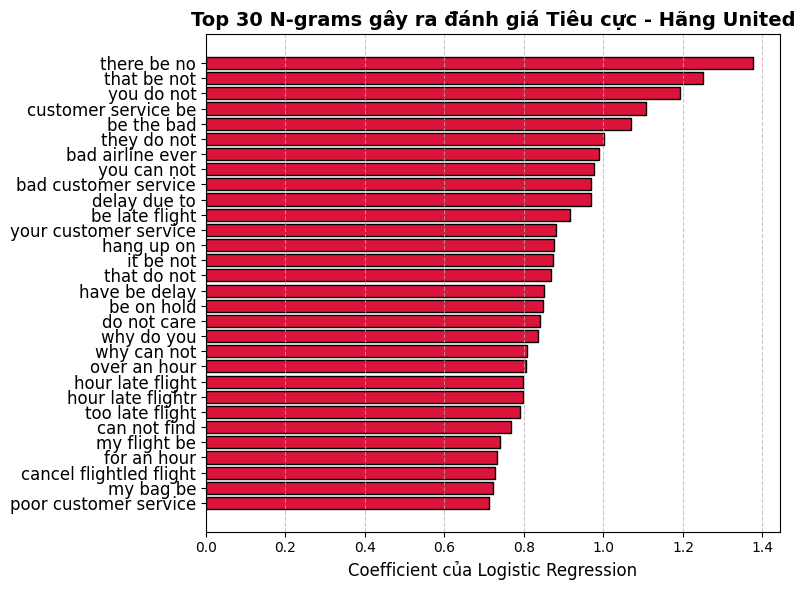

,N-gram,Coefficient
0,there be no,1.375308
1,that be not,1.251458
2,you do not,1.191435
3,customer service be,1.106158
4,be the bad,1.069758
5,they do not,1.000399
6,bad airline ever,0.988722
7,you can not,0.975034
8,bad customer service,0.969605
9,delay due to,0.968116



=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===


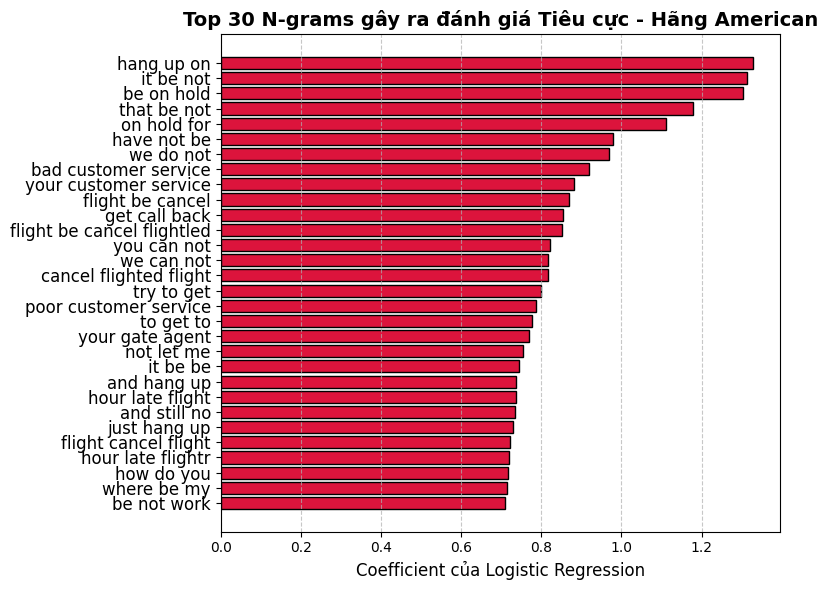

,N-gram,Coefficient
0,hang up on,1.329002
1,it be not,1.311989
2,be on hold,1.303479
3,that be not,1.177852
4,on hold for,1.110849
5,have not be,0.978504
6,we do not,0.968308
7,bad customer service,0.919867
8,your customer service,0.880390
9,flight be cancel,0.869264


In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_top_negative_ngrams(df, airline_name, top_n=15):
    """
    Hàm lọc dữ liệu theo hãng, dùng TF-IDF + LR để tìm và vẽ Top N-grams 
    có trọng số dự đoán Negative cao nhất.
    """
    # 1. Lọc dữ liệu của hãng cụ thể
    df_airline = df[df['airline'] == airline_name].copy()
    
    df_airline = df_airline.dropna(subset=['text_preprocessed'])
    
    # Loại bỏ các dòng text rỗng sau khi tiền xử lý
    df_airline = df_airline[df_airline['text_preprocessed'].str.strip() != '']
    
    X_text = df_airline['text_preprocessed']
    y = df_airline['airline_sentiment']
    
    # 2. Vector hóa bằng TF-IDF (ngrams 1 và 2 như yêu cầu đề bài)
    tfidf = TfidfVectorizer(ngram_range=(3, 4), max_features=5000)
    X_tfidf = tfidf.fit_transform(X_text)
    
    # 3. Huấn luyện Logistic Regression
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_tfidf, y)
    
    # 4. Trích xuất hệ số (Coefficient)
    # Lấy index của lớp 'negative' trong mảng lr.classes_
    neg_idx = list(lr.classes_).index('negative')
    
    # Lấy trọng số của tất cả các n-grams đối với lớp negative
    coefs = lr.coef_[neg_idx]
    feature_names = np.array(tfidf.get_feature_names_out())
    
    # Lấy ra index của top_n n-grams có trọng số ĐƯƠNG cao nhất 
    # (trọng số càng lớn, khả năng đẩy dự đoán về 'negative' càng cao)
    top_indices = coefs.argsort()[-top_n:][::-1]
    
    top_features = feature_names[top_indices]
    top_coefs = coefs[top_indices]
    
    # 5. Vẽ biểu đồ trực quan
    plt.figure(figsize=(8, 6))
    # Sắp xếp lại để vẽ thanh barh đẹp hơn (từ cao xuống thấp)
    y_pos = np.arange(len(top_features))
    plt.barh(y_pos, top_coefs[::-1], color='crimson', edgecolor='black')
    plt.yticks(y_pos, top_features[::-1], fontsize=12)
    plt.xlabel('Coefficient của Logistic Regression', fontsize=12)
    plt.title(f'Top {top_n} N-grams gây ra đánh giá Tiêu cực - Hãng {airline_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Trả về dataframe để in bảng nếu cần
    return pd.DataFrame({'N-gram': top_features, 'Coefficient': top_coefs})

# Khởi chạy cho United Airlines
print("=== PHÂN TÍCH HÃNG UNITED AIRLINES ===")
united_top_ngrams = plot_top_negative_ngrams(df, 'United', top_n=30)
display(united_top_ngrams)

# Khởi chạy cho American Airlines
print("\n=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===")
american_top_ngrams = plot_top_negative_ngrams(df, 'American', top_n=30)
display(american_top_ngrams)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier # ĐỔI SANG MÔ HÌNH RANDOM FOREST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_top_negative_ngrams_rf(df, airline_name, top_n=15):
    """
    Sử dụng TF-IDF và Random Forest để trích xuất Feature Importance.
    """
    # 1. Lọc và làm sạch dữ liệu
    df_airline = df[df['airline'] == airline_name].copy()
    df_airline = df_airline.dropna(subset=['text_preprocessed'])
    df_airline = df_airline[df_airline['text_preprocessed'].str.strip() != '']
    
    X_text = df_airline['text_preprocessed']
    # Đưa y về dạng nhị phân: 'negative' (1) và 'các nhãn khác' (0) để đo Feature Importance cho Negative dễ hơn
    y = (df_airline['airline_sentiment'] == 'negative').astype(int) 
    
    # 2. Vector hóa
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
    X_tfidf = tfidf.fit_transform(X_text)
    
    # 3. Huấn luyện Random Forest
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X_tfidf, y)
    
    # 4. Trích xuất FEATURE IMPORTANCES
    # Khác với coef_ có âm/dương, feature_importances_ luôn >= 0 
    # và biểu thị mức độ "đóng góp" của n-gram vào việc phân loại
    importances = rf.feature_importances_ 
    feature_names = np.array(tfidf.get_feature_names_out())
    
    # Lấy ra index top N quan trọng nhất
    top_indices = importances.argsort()[-top_n:][::-1]
    
    top_features = feature_names[top_indices]
    top_importances = importances[top_indices]
    
    # 5. Vẽ biểu đồ 
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(top_features))
    plt.barh(y_pos, top_importances[::-1], color='darkorange', edgecolor='black')
    plt.yticks(y_pos, top_features[::-1], fontsize=12)
    plt.xlabel('Feature Importance (Random Forest)', fontsize=12)
    plt.title(f'Top {top_n} N-grams quan trọng nhất phân loại Negative - {airline_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame({'N-gram': top_features, 'Feature Importance': top_importances})


=== PHÂN TÍCH HÃNG UNITED AIRLINES ===


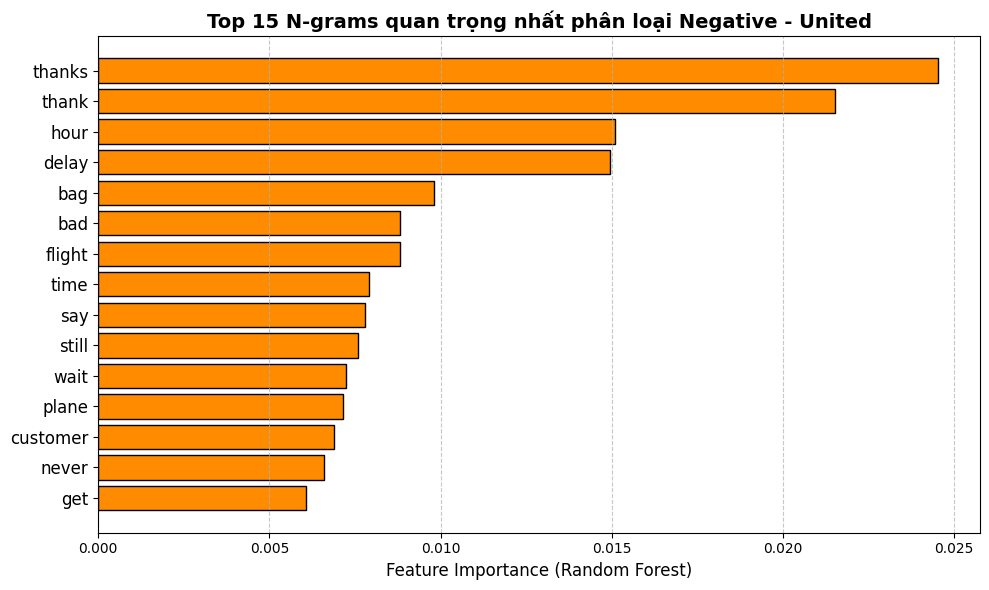

,N-gram,Feature Importance
0,thanks,0.024527
1,thank,0.021517
2,hour,0.015095
3,delay,0.014950
4,bag,0.009815
5,bad,0.008808
6,flight,0.008805
7,time,0.007898
8,say,0.007794
9,still,0.007592



=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===


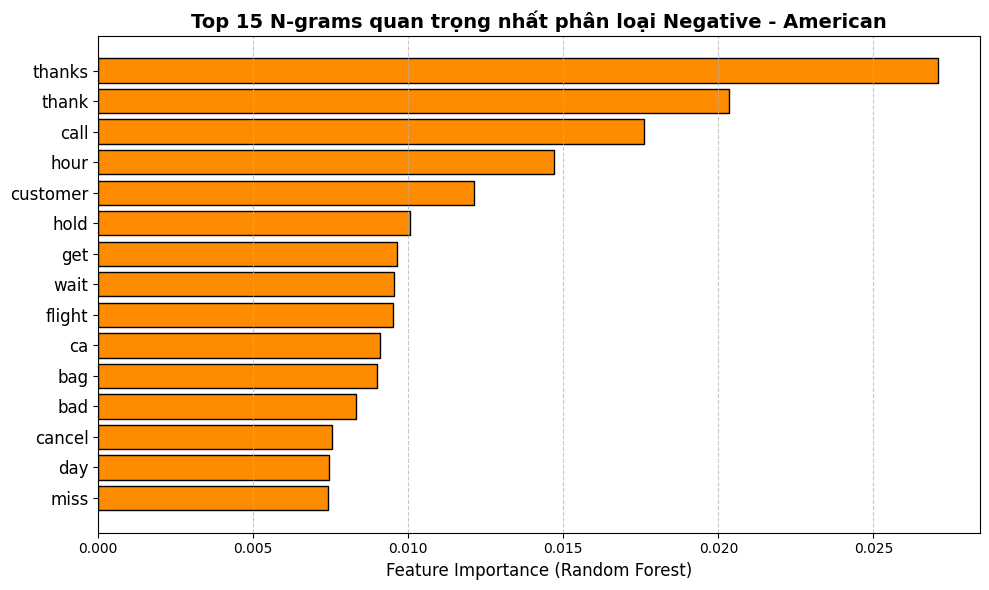

,N-gram,Feature Importance
0,thanks,0.027084
1,thank,0.020360
2,call,0.017600
3,hour,0.014717
4,customer,0.012112
5,hold,0.010071
6,get,0.009640
7,wait,0.009548
8,flight,0.009514
9,ca,0.009080


In [28]:
# Khởi chạy cho United Airlines
print("=== PHÂN TÍCH HÃNG UNITED AIRLINES ===")
united_top_ngrams = plot_top_negative_ngrams_rf(df, 'United', top_n=15)
display(united_top_ngrams)

# Khởi chạy cho American Airlines
print("\n=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===")
american_top_ngrams = plot_top_negative_ngrams_rf(df, 'American', top_n=15)
display(american_top_ngrams)